# Bayesian Panel Data Model

This notebook implements a Bayesian hierarchical panel model to analyze HALE and Life Expectancy gender gaps using both temporal variation and cross-country variation simultaneously. The temporal range is configurable (default: 2000-2019, can be extended to 2021 to include COVID years). Note: The cutoff year is limited to 2021 because HALE and Life Expectancy data from WHO are only available through 2021.

## Overview

The panel data approach provides more statistical power and allows us to model how relationships between indicators and gender gaps evolve over time, while accounting for country-specific characteristics.

**Model Structure:**
- Bayesian hierarchical model with country-level random intercepts
- Shared slopes for all predictors (same across all countries)
- Uses both within-country and between-country variation
- Controls for time-invariant country-level factors

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pymc as pm
import matplotlib.pyplot as plt
import arviz as az

from utils import (
    decorate, underride, configure_plot_style, AIBM_COLORS,
    load_and_inventory, compute_gender_gap, get_oecd,
    load_ihme_indicator, column_name_mapping, oecd_codes,
    write_html_table
)

configure_plot_style()

In [3]:
import sys
import IPython
from utils import beep

def beep_on_error(shell, etype, evalue, tb, tb_offset=None):
    beep()  
    # Call the original handler so the traceback still appears
    shell.showtraceback((etype, evalue, tb), tb_offset=tb_offset)

ip = IPython.get_ipython()
ip.set_custom_exc((Exception,), beep_on_error)

## Model Configuration

In [4]:
# ============================================================================
# MODEL CONFIGURATION: TEMPORAL CUTOFF AND COVID DATA
# ============================================================================
# Global variable: Whether to include COVID-19 data as a predictor
# Set to True to include COVID-19 death rates as a predictor and extend analysis to 2021
# Set to False to exclude COVID-19 and use pre-COVID baseline (2000-2019)
# Note: Cutoff year is limited to 2021 because HALE and Life Expectancy data from WHO
# are only available through 2021, even though COVID-19 data extends to 2023.
INCLUDE_COVID_DATA = True

# Cutoff year is automatically determined by COVID flag
# True -> 2021 (includes COVID years, limited by HALE/LE data availability), False -> 2019 (pre-COVID baseline)
CUTOFF_YEAR = 2021 if INCLUDE_COVID_DATA else 2019

# Global variable: List of countries to exclude from analysis
# Set to empty list [] to include all countries
# Example: COUNTRIES_TO_EXCLUDE = ['TUR'] to exclude Turkey
COUNTRIES_TO_EXCLUDE = ['TUR']

print(f"Model Configuration:")
print(f"  Include COVID Data: {INCLUDE_COVID_DATA}")
print(f"  Cutoff Year: {CUTOFF_YEAR} (automatically set based on COVID flag)")
print(f"  Countries Excluded: {COUNTRIES_TO_EXCLUDE}")

Model Configuration:
  Include COVID Data: True
  Cutoff Year: 2021 (automatically set based on COVID flag)
  Countries Excluded: ['TUR']


## Data Preparation

### Helper Function: Compute Temporal Gaps

We need a function that preserves all years (not just most recent) to create panel data:

In [5]:
def compute_temporal_gaps(df, value_col, sexes=['Male', 'Female']):
    """
    Compute gender gaps for all years (not just most recent).
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with Year, Code, Sex, and value_col columns
    value_col : str
        Name of the value column
    sexes : list
        List of sex values to compare
        
    Returns
    -------
    df_gaps : pandas.DataFrame
        DataFrame with Gap and Mid columns for all years
    """
    return compute_gender_gap(df, value_col, sexes)

### Load Target Variables

#### HALE Data

In [6]:
filename = '../data/who_hale_data.csv'
hale, years = load_and_inventory(filename, cutoff_year=CUTOFF_YEAR)

(12210, 10)
['SEX_BTSX' 'SEX_FMLE' 'SEX_MLE']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021]


In [7]:
# Map sex codes to standard names
sex_mapping = {'SEX_BTSX': 'Both', 'SEX_FMLE': 'Female', 'SEX_MLE': 'Male'}
hale['Sex'] = hale['Sex'].replace(sex_mapping)

In [8]:
# Compute gaps for all years (preserve temporal structure)
# Note: compute_gender_gap computes Gap as Male - Female, but we want Female - Male
hale_temporal = compute_temporal_gaps(hale, 'HALE_Years', sexes=['Male', 'Female'])
# Calculate gap as Female - Male (positive gap means women live longer)
# Gap_HALE_Years is Male - Female, so we negate it
hale_temporal['HALE_gap'] = -hale_temporal['Gap_HALE_Years']
hale_temporal.head()

,Code,Year,HALE_Years_Male,HALE_Years_Female,Gap_HALE_Years,Mid_HALE_Years,Country,HALE_gap
0,AFG,2000,45.943669,46.154851,-0.211182,46.049260,Afghanistan,0.211182
1,AFG,2001,45.989073,46.284875,-0.295802,46.136974,Afghanistan,0.295802
2,AFG,2002,47.407615,46.994510,0.413105,47.201063,Afghanistan,-0.413105
3,AFG,2003,48.291904,47.702906,0.588998,47.997405,Afghanistan,-0.588998
4,AFG,2004,48.637754,48.050686,0.587069,48.344220,Afghanistan,-0.587069


#### Life Expectancy Data

In [9]:
filename = '../data/who_life_expectancy_data.csv'
le, years = load_and_inventory(filename, cutoff_year=CUTOFF_YEAR)

(12210, 10)
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021]


In [10]:
# Map sex codes to standard names
le['Sex'] = le['Sex'].replace(sex_mapping)

In [11]:
# Compute gaps for all years (preserve temporal structure)
# Note: compute_gender_gap computes Gap as Male - Female, but we want Female - Male
le_temporal = compute_temporal_gaps(le, 'LifeExpectancy_Years', sexes=['Male', 'Female'])
# Calculate gap as Female - Male (positive gap means women live longer)
# Gap_LifeExpectancy_Years is Male - Female, so we negate it
le_temporal['LE_gap'] = -le_temporal['Gap_LifeExpectancy_Years']
le_temporal.head()

,Code,Year,LifeExpectancy_Years_Male,LifeExpectancy_Years_Female,Gap_LifeExpectancy_Years,Mid_LifeExpectancy_Years,Country,LE_gap
0,AFG,2000,53.249991,54.429579,-1.179588,53.839785,Afghanistan,1.179588
1,AFG,2001,53.284639,54.570059,-1.285419,53.927349,Afghanistan,1.285419
2,AFG,2002,54.921993,55.401586,-0.479593,55.161789,Afghanistan,0.479593
3,AFG,2003,55.949458,56.242837,-0.293379,56.096147,Afghanistan,0.293379
4,AFG,2004,56.329965,56.647472,-0.317507,56.488719,Afghanistan,0.317507


### Load Predictor Indicators

We'll load all indicators used in the final model. For panel analysis, we need to preserve all years, so we use `compute_temporal_gaps` instead of `summarize_gap`.

#### Helper Function for Loading IHME Indicators

In [12]:
def load_ihme_indicator_temporal(base_filename, value_col_name, indicator_code, indicator_name, max_year=2019):
    """
    Load IHME indicator data and compute temporal gaps for all years.
    
    Parameters
    ----------
    base_filename : str
        Base filename without path, sex suffix, or extension (e.g., 'ihme_alcohol_use_disorders_deaths')
    value_col_name : str
        Name of the value column (e.g., 'AlcoholUseDisordersDeathRate')
    indicator_code : str
        Indicator code (e.g., 'IHME_ALCOHOL_USE_DISORDERS')
    indicator_name : str
        Human-readable indicator name
    max_year : int, optional
        Maximum year to include. Default is 2019.
        
    Returns
    -------
    df_temporal : pandas.DataFrame
        DataFrame with temporal gaps computed for all years
    """
    
    filename_male = f'../data/{base_filename}_male.csv'
    filename_female = f'../data/{base_filename}_female.csv'
    df = load_ihme_indicator(
        filename_male, filename_female,
        value_col_name=value_col_name,
        indicator_code=indicator_code,
        indicator_name=indicator_name,
        min_year=2000,
        max_year=max_year
    )
    df = df.rename(columns=column_name_mapping)
    col = column_name_mapping.get(value_col_name, value_col_name)
    df_temporal = compute_temporal_gaps(df, col, sexes=['Male', 'Female'])
    return df_temporal

#### Alcohol Use Disorders (IHME)

In [13]:
alcohol_temporal = load_ihme_indicator_temporal(
    'ihme_alcohol_use_disorders_deaths',
    'AlcoholUseDisordersDeathRate',
    'IHME_ALCOHOL_USE_DISORDERS',
    'Alcohol use disorders, death rate per 100,000',
    max_year=CUTOFF_YEAR
)
alcohol_temporal.head()

,Code,Year,Alcohol_Male,Alcohol_Female,Gap_Alcohol,Mid_Alcohol,Country
0,AUS,2000.0,2.734867,0.631488,2.103379,1.683177,Australia
1,AUS,2001.0,2.651414,0.616363,2.035051,1.633888,Australia
2,AUS,2002.0,2.712614,0.672539,2.040075,1.692577,Australia
3,AUS,2003.0,2.686314,0.680933,2.005382,1.683623,Australia
4,AUS,2004.0,2.626829,0.704165,1.922664,1.665497,Australia


#### Self-Harm (IHME)

In [14]:
self_harm_temporal = load_ihme_indicator_temporal(
    'ihme_self_harm_deaths',
    'SelfHarmDeathRate',
    'IHME_SELF_HARM',
    'Self-harm (suicide), death rate per 100,000',
    max_year=CUTOFF_YEAR
)
self_harm_temporal.head()

,Code,Year,Suicide_Male,Suicide_Female,Gap_Suicide,Mid_Suicide,Country
0,AUS,2000.0,21.632300,5.627537,16.004763,13.629919,Australia
1,AUS,2001.0,20.813040,5.677859,15.135181,13.245450,Australia
2,AUS,2002.0,19.557416,5.484698,14.072718,12.521057,Australia
3,AUS,2003.0,18.599332,5.150209,13.449123,11.874770,Australia
4,AUS,2004.0,18.148308,4.923421,13.224887,11.535865,Australia


#### Interpersonal Violence (IHME)

In [15]:
interpersonal_violence_temporal = load_ihme_indicator_temporal(
    'ihme_interpersonal_violence_deaths',
    'InterpersonalViolenceDeathRate',
    'IHME_INTERPERSONAL_VIOLENCE',
    'Interpersonal violence (homicide), death rate per 100,000',
    max_year=CUTOFF_YEAR
)
interpersonal_violence_temporal.head()

,Code,Year,Homicide_Male,Homicide_Female,Gap_Homicide,Mid_Homicide,Country
0,AUS,2000.0,2.246983,1.220574,1.026409,1.733778,Australia
1,AUS,2001.0,2.213900,1.155846,1.058054,1.684873,Australia
2,AUS,2002.0,2.095225,1.080767,1.014458,1.587996,Australia
3,AUS,2003.0,1.880337,0.889872,0.990465,1.385104,Australia
4,AUS,2004.0,1.495477,0.758536,0.736941,1.127007,Australia


#### Road Injuries (IHME)

In [16]:
road_injuries_temporal = load_ihme_indicator_temporal(
    'ihme_road_injuries_deaths',
    'RoadInjuriesDeathRate',
    'IHME_ROAD_INJURIES',
    'Road injuries (road traffic crashes), death rate per 100,000',
    max_year=CUTOFF_YEAR
)
road_injuries_temporal.head()

,Code,Year,RoadTraffic_Male,RoadTraffic_Female,Gap_RoadTraffic,Mid_RoadTraffic,Country
0,AUS,2000.0,15.184325,6.084094,9.100231,10.634210,Australia
1,AUS,2001.0,14.674288,5.782579,8.891709,10.228433,Australia
2,AUS,2002.0,13.989668,5.545272,8.444396,9.767470,Australia
3,AUS,2003.0,13.230099,5.210589,8.019510,9.220344,Australia
4,AUS,2004.0,12.930886,4.897544,8.033342,8.914215,Australia


#### Cardiovascular Disease (IHME)

In [17]:
cardiovascular_temporal = load_ihme_indicator_temporal(
    'ihme_cardiovascular_deaths',
    'CardioDeathRate',
    'IHME_CARDIOVASCULAR',
    'Cardiovascular diseases, death rate per 100,000',
    max_year=CUTOFF_YEAR
)
cardiovascular_temporal.head()

,Code,Year,Cardiovascular_Male,Cardiovascular_Female,Gap_Cardiovascular,Mid_Cardiovascular,Country
0,AUS,2000.0,251.531993,259.494605,-7.962612,255.513299,Australia
1,AUS,2001.0,245.860127,253.477767,-7.617639,249.668947,Australia
2,AUS,2002.0,245.223115,253.122588,-7.899473,249.172852,Australia
3,AUS,2003.0,236.409743,244.429433,-8.019690,240.419588,Australia
4,AUS,2004.0,228.397267,235.278983,-6.881717,231.838125,Australia


#### Diabetes (IHME)

In [18]:
diabetes_temporal = load_ihme_indicator_temporal(
    'ihme_diabetes_deaths',
    'DiabetesDeathRate',
    'IHME_DIABETES_TYPE2',
    'Diabetes mellitus type 2, death rate per 100,000',
    max_year=CUTOFF_YEAR
)
diabetes_temporal.head()

,Code,Year,Diabetes_Male,Diabetes_Female,Gap_Diabetes,Mid_Diabetes,Country
0,AUS,2000.0,16.568642,14.248627,2.320015,15.408635,Australia
1,AUS,2001.0,17.037716,14.344688,2.693028,15.691202,Australia
2,AUS,2002.0,17.960180,14.975359,2.984820,16.467769,Australia
3,AUS,2003.0,18.379621,15.525666,2.853954,16.952644,Australia
4,AUS,2004.0,18.334611,16.080445,2.254167,17.207528,Australia


#### Neoplasms (IHME)

In [19]:
neoplasms_temporal = load_ihme_indicator_temporal(
    'ihme_neoplasms_deaths',
    'NeoplasmsDeathRate',
    'IHME_NEOPLASMS',
    'Neoplasms (cancer), death rate per 100,000',
    max_year=CUTOFF_YEAR
)
neoplasms_temporal.head()

,Code,Year,Neoplasms_Male,Neoplasms_Female,Gap_Neoplasms,Mid_Neoplasms,Country
0,AUS,2000.0,229.808667,174.372594,55.436073,202.090630,Australia
1,AUS,2001.0,230.943004,176.862341,54.080663,203.902673,Australia
2,AUS,2002.0,233.465215,179.519671,53.945544,206.492443,Australia
3,AUS,2003.0,232.827329,178.595845,54.231484,205.711587,Australia
4,AUS,2004.0,233.886844,177.584662,56.302182,205.735753,Australia


#### Chronic Respiratory Disease (IHME)

In [20]:
chronic_respiratory_temporal = load_ihme_indicator_temporal(
    'ihme_chronic_respiratory_deaths',
    'ChronicRespiratoryDeathRate',
    'IHME_CHRONIC_RESPIRATORY',
    'Chronic respiratory diseases, death rate per 100,000',
    max_year=CUTOFF_YEAR
)
chronic_respiratory_temporal.head()

,Code,Year,ChronicRespiratory_Male,ChronicRespiratory_Female,Gap_ChronicRespiratory,Mid_ChronicRespiratory,Country
0,AUS,2000.0,47.317193,33.416935,13.900258,40.367064,Australia
1,AUS,2001.0,46.003680,33.538075,12.465605,39.770878,Australia
2,AUS,2002.0,46.598934,34.771695,11.827239,40.685314,Australia
3,AUS,2003.0,44.267105,34.102959,10.164146,39.185032,Australia
4,AUS,2004.0,42.134910,33.381971,8.752940,37.758441,Australia


#### Liver Disease (IHME)

In [21]:
liver_disease_temporal = load_ihme_indicator_temporal(
    'ihme_liver_disease_deaths',
    'LiverDiseaseDeathRate',
    'IHME_LIVER_DISEASE',
    'Cirrhosis and other chronic liver diseases, death rate per 100,000',
    max_year=CUTOFF_YEAR
)
liver_disease_temporal.head()

,Code,Year,LiverDisease_Male,LiverDisease_Female,Gap_LiverDisease,Mid_LiverDisease,Country
0,AUS,2000.0,9.277966,4.125954,5.152012,6.701960,Australia
1,AUS,2001.0,9.433355,4.028933,5.404421,6.731144,Australia
2,AUS,2002.0,9.887432,4.357130,5.530302,7.122281,Australia
3,AUS,2003.0,10.141958,4.273111,5.868847,7.207535,Australia
4,AUS,2004.0,10.222984,4.275616,5.947368,7.249300,Australia


#### Unintentional Injuries (IHME)

In [22]:
unintentional_injuries_temporal = load_ihme_indicator_temporal(
    'ihme_unintentional_injuries_deaths',
    'UnintentionalInjuriesDeathRate',
    'IHME_UNINTENTIONAL_INJURIES',
    'Unintentional injuries, death rate per 100,000',
    max_year=CUTOFF_YEAR
)
unintentional_injuries_temporal.head()

,Code,Year,UnintentionalInjury_Male,UnintentionalInjury_Female,Gap_UnintentionalInjury,Mid_UnintentionalInjury,Country
0,AUS,2000.0,14.719270,12.032874,2.686396,13.376072,Australia
1,AUS,2001.0,14.106178,11.824066,2.282112,12.965122,Australia
2,AUS,2002.0,15.206234,12.696670,2.509564,13.951452,Australia
3,AUS,2003.0,15.927738,13.010010,2.917728,14.468874,Australia
4,AUS,2004.0,16.703760,13.977934,2.725826,15.340847,Australia


#### Drug Use Disorders (IHME)

In [23]:
drug_disorders_temporal = load_ihme_indicator_temporal(
    'ihme_drug_disorder_deaths',
    'DrugDisorderDeathRate',
    'IHME_DRUG_DISORDERS',
    'Drug use disorders, death rate per 100,000',
    max_year=CUTOFF_YEAR
)
drug_disorders_temporal.head()

,Code,Year,DrugDisorder_Male,DrugDisorder_Female,Gap_DrugDisorder,Mid_DrugDisorder,Country
0,AUS,2000.0,7.786561,2.882676,4.903885,5.334618,Australia
1,AUS,2001.0,6.381747,2.664587,3.717160,4.523167,Australia
2,AUS,2002.0,5.610826,2.499320,3.111505,4.055073,Australia
3,AUS,2003.0,5.310132,2.420756,2.889375,3.865444,Australia
4,AUS,2004.0,5.165104,2.357760,2.807344,3.761432,Australia


#### COVID-19 (IHME)

In [24]:
# Load COVID-19 data (will be conditionally included in model based on INCLUDE_COVID_DATA flag)
covid_temporal = load_ihme_indicator_temporal(
    'ihme_covid19_deaths',
    'COVID19DeathRate',
    'IHME_COVID19',
    'COVID-19, death rate per 100,000',
    max_year=CUTOFF_YEAR
)
covid_temporal.head()

,Code,Year,COVID_Male,COVID_Female,Gap_COVID,Mid_COVID,Country
0,AUS,2000.0,0.0,0.0,0.0,0.0,Australia
1,AUS,2001.0,0.0,0.0,0.0,0.0,Australia
2,AUS,2002.0,0.0,0.0,0.0,0.0,Australia
3,AUS,2003.0,0.0,0.0,0.0,0.0,Australia
4,AUS,2004.0,0.0,0.0,0.0,0.0,Australia


### Merge All Data into Panel Format

Now we'll merge all indicators into a single panel dataset with one row per country-year:

In [25]:
# Start with HALE gap as base
panel_df = hale_temporal[['Code', 'Year', 'HALE_gap']].copy()
panel_df = panel_df.rename(columns={'Code': 'country'})

# Add Life Expectancy gap
le_panel = le_temporal[['Code', 'Year', 'LE_gap']].copy()
le_panel = le_panel.rename(columns={'Code': 'country'})
panel_df = panel_df.merge(le_panel, on=['country', 'Year'], how='outer')

# Function to merge predictor indicators
def merge_predictor(df_temporal, indicator_name):
    """Merge a predictor indicator into the panel dataset."""
    # Select relevant columns (Code, Year, Mid_*, Gap_*)
    cols_to_merge = ['Code', 'Year']
    mid_col = [c for c in df_temporal.columns if c.startswith('Mid_')]
    gap_col = [c for c in df_temporal.columns if c.startswith('Gap_')]
    cols_to_merge.extend(mid_col)
    cols_to_merge.extend(gap_col)
    
    df_subset = df_temporal[cols_to_merge].copy()
    df_subset = df_subset.rename(columns={'Code': 'country'})
    return df_subset

# Merge all predictors
predictors_to_merge = [
    (alcohol_temporal, 'Alcohol'),
    (self_harm_temporal, 'SelfHarm'),
    (interpersonal_violence_temporal, 'InterpersonalViolence'),
    (road_injuries_temporal, 'RoadInjuries'),
    (cardiovascular_temporal, 'Cardiovascular'),
    (diabetes_temporal, 'Diabetes'),
    (neoplasms_temporal, 'Neoplasms'),
    (chronic_respiratory_temporal, 'ChronicRespiratory'),
    (liver_disease_temporal, 'LiverDisease'),
    (unintentional_injuries_temporal, 'UnintentionalInjuries'),
    (drug_disorders_temporal, 'DrugDisorder'),
]

# Conditionally add COVID-19 data
if INCLUDE_COVID_DATA:
    predictors_to_merge.append((covid_temporal, 'COVID19'))

for df_temp, name in predictors_to_merge:
    df_merge = merge_predictor(df_temp, name)
    panel_df = panel_df.merge(df_merge, on=['country', 'Year'], how='outer')
    print(f"Merged {name}: {len(df_merge)} rows")

print(f"\nFinal panel dataset shape: {panel_df.shape}")
print(f"Columns: {list(panel_df.columns)}")

Merged Alcohol: 836 rows
Merged SelfHarm: 836 rows
Merged InterpersonalViolence: 836 rows
Merged RoadInjuries: 836 rows
Merged Cardiovascular: 836 rows
Merged Diabetes: 836 rows
Merged Neoplasms: 836 rows
Merged ChronicRespiratory: 836 rows
Merged LiverDisease: 836 rows
Merged UnintentionalInjuries: 836 rows
Merged DrugDisorder: 836 rows
Merged COVID19: 836 rows

Final panel dataset shape: (4070, 28)
Columns: ['country', 'Year', 'HALE_gap', 'LE_gap', 'Mid_Alcohol', 'Gap_Alcohol', 'Mid_Suicide', 'Gap_Suicide', 'Mid_Homicide', 'Gap_Homicide', 'Mid_RoadTraffic', 'Gap_RoadTraffic', 'Mid_Cardiovascular', 'Gap_Cardiovascular', 'Mid_Diabetes', 'Gap_Diabetes', 'Mid_Neoplasms', 'Gap_Neoplasms', 'Mid_ChronicRespiratory', 'Gap_ChronicRespiratory', 'Mid_LiverDisease', 'Gap_LiverDisease', 'Mid_UnintentionalInjury', 'Gap_UnintentionalInjury', 'Mid_DrugDisorder', 'Gap_DrugDisorder', 'Mid_COVID', 'Gap_COVID']


In [26]:
# Filter to OECD countries
panel_df = panel_df[panel_df['country'].isin(oecd_codes)].copy()
print(f"After filtering to OECD: {panel_df.shape}")

# Filter to years 2000-CUTOFF_YEAR
panel_df = panel_df[(panel_df['Year'] >= 2000) & (panel_df['Year'] <= CUTOFF_YEAR)].copy()
print(f"After filtering to 2000-{CUTOFF_YEAR}: {panel_df.shape}")

# Conditionally exclude countries based on global variable
if COUNTRIES_TO_EXCLUDE:
    n_before = len(panel_df)
    panel_df = panel_df[~panel_df['country'].isin(COUNTRIES_TO_EXCLUDE)].copy()
    n_after = len(panel_df)
    print(f"After excluding {COUNTRIES_TO_EXCLUDE}: {panel_df.shape} (removed {n_before - n_after} rows)")
else:
    print(f"No countries excluded")

# Sort by country and year
panel_df = panel_df.sort_values(['country', 'Year']).reset_index(drop=True)
panel_df.head()

After filtering to OECD: (836, 28)
After filtering to 2000-2021: (836, 28)
After excluding ['TUR']: (814, 28) (removed 22 rows)


,country,Year,HALE_gap,LE_gap,Mid_Alcohol,Gap_Alcohol,Mid_Suicide,Gap_Suicide,Mid_Homicide,Gap_Homicide,...,Mid_ChronicRespiratory,Gap_ChronicRespiratory,Mid_LiverDisease,Gap_LiverDisease,Mid_UnintentionalInjury,Gap_UnintentionalInjury,Mid_DrugDisorder,Gap_DrugDisorder,Mid_COVID,Gap_COVID
0,AUS,2000,2.385148,5.117413,1.683177,2.103379,13.629919,16.004763,1.733778,1.026409,...,40.367064,13.900258,6.701960,5.152012,13.376072,2.686396,5.334618,4.903885,0.0,0.0
1,AUS,2001,2.287445,5.025503,1.633888,2.035051,13.245450,15.135181,1.684873,1.058054,...,39.770878,12.465605,6.731144,5.404421,12.965122,2.282112,4.523167,3.717160,0.0,0.0
2,AUS,2002,2.050956,4.759476,1.692577,2.040075,12.521057,14.072718,1.587996,1.014458,...,40.685314,11.827239,7.122281,5.530302,13.951452,2.509564,4.055073,3.111505,0.0,0.0
3,AUS,2003,1.982985,4.698802,1.683623,2.005382,11.874770,13.449123,1.385104,0.990465,...,39.185032,10.164146,7.207535,5.868847,14.468874,2.917728,3.865444,2.889375,0.0,0.0
4,AUS,2004,1.906233,4.627694,1.665497,1.922664,11.535865,13.224887,1.127007,0.736941,...,37.758441,8.752940,7.249300,5.947368,15.340847,2.725826,3.761432,2.807344,0.0,0.0


In [27]:
# Check for missing data
print("Missing data summary:")
print(panel_df.isnull().sum().sum(), "total missing values")
print("\nMissing values by column:")
missing_by_col = panel_df.isnull().sum()
print(missing_by_col[missing_by_col > 0])

Missing data summary:
0 total missing values

Missing values by column:
Series([], dtype: int64)


In [28]:
# Check data coverage
print("Data coverage:")
print(f"Countries: {panel_df['country'].nunique()}")
print(f"Years: {sorted(panel_df['Year'].unique())}")
print(f"Country-year combinations: {len(panel_df)}")

Data coverage:
Countries: 37
Years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Country-year combinations: 814


## Prepare Panel Data for Modeling

Now we'll use the `prepare_panel_data` function to standardize predictors and center targets:

In [29]:
def prepare_panel_data(df, predictor_cols, target_col):
    """
    Prepare panel data for Bayesian modeling.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Long-format DataFrame with columns:
        - 'country' (str)
        - 'year' (int)
        - target_col (float, HALE_gap or LE_gap in years)
        - predictor_cols (float)
    
    Returns
    -------
    data_dict : dict
        Dictionary with:
            X          : (N, P) ndarray of standardized predictors
            y_centered : (N,) ndarray of centered target
            country_idx: (N,) int array in [0, n_country-1]
            year_idx   : (N,) int array in [0, n_year-1]
            coords     : dict for PyMC Model(coords=...)
            meta       : dict with means/SDs for later use
    """
    df = df.copy()
    
    # Unique levels
    countries = np.sort(df["country"].unique())
    years = np.sort(df["year"].unique())
    predictors = list(predictor_cols)
    
    country_indexer = {c: i for i, c in enumerate(countries)}
    year_indexer = {y: i for i, y in enumerate(years)}
    
    df["country_idx"] = df["country"].map(country_indexer)
    df["year_idx"] = df["year"].map(year_indexer)
    
    # Extract raw matrices/vectors
    X_raw = df[predictor_cols].to_numpy(dtype=float)
    y_raw = df[target_col].to_numpy(dtype=float)
    country_idx = df["country_idx"].to_numpy(dtype=int)
    year_idx = df["year_idx"].to_numpy(dtype=int)
    
    # Standardize predictors across all country–year rows
    X_mean = X_raw.mean(axis=0)
    X_std = X_raw.std(axis=0, ddof=0)
    # Guard against any zero variance columns
    X_std_safe = np.where(X_std == 0, 1.0, X_std)
    X = (X_raw - X_mean) / X_std_safe
    
    # Center target (keep units in years)
    y_mean = y_raw.mean()
    y_centered = y_raw - y_mean
    
    N, P = X.shape
    
    coords = {
        "obs": np.arange(N),
        "country": countries,
        "year": years,
        "predictor": predictors,
    }
    
    data_dict = {
        "X": X,
        "y_centered": y_centered,
        "country_idx": country_idx,
        "year_idx": year_idx,
        "coords": coords,
        "meta": {
            "X_mean": X_mean,
            "X_std": X_std_safe,
            "y_mean": y_mean,
            "countries": countries,
            "years": years,
            "predictors": predictors,
        },
    }
    
    return data_dict

In [30]:
# ============================================================================
# MODEL CONFIGURATION
# ============================================================================
# Configure which Mid predictors to include in the model
# Options: [] (baseline - Gap predictors only)
#          ['Mid_Cardiovascular'] (add Mid_Cardiovascular)
#          ['Mid_Cardiovascular', 'Mid_Diabetes'] (add multiple)
#          etc.
#
# Testing order (from plan.md):
#   1. Mid_Cardiovascular (r = -0.804 with Gap_Cardiovascular)
#   2. Mid_Diabetes (r = -0.325 with Gap_Diabetes)
#   3. Mid_ChronicRespiratory (r = -0.0787 with Gap_ChronicRespiratory)
#   4. Mid_UnintentionalInjury (r = 0.0346 with Gap_UnintentionalInjury)
#
# Start with baseline: MID_PREDICTORS_TO_INCLUDE = []
# Then test each candidate one at a time, adding to list if it improves model
#
# Experiment status:
#   - Baseline ([]): ✅ COMPLETED - OPTIMAL MODEL (WAIC 75.7 HALE, -7.44 LE)
#   - Mid_Cardiovascular: ✅ COMPLETED - worsened fit (ΔWAIC +51.3 HALE, +62.5 LE)
#   - Mid_Diabetes: ✅ COMPLETED - worsened fit (ΔWAIC +3.1 HALE, +2.18 LE)
#   - Mid_ChronicRespiratory: ✅ COMPLETED - worsened fit (ΔWAIC +20.8 HALE, +24.1 LE)
#   - Mid_UnintentionalInjury: ✅ COMPLETED - worsened fit (ΔWAIC +79.3 HALE, +91.1 LE)
#   - ALL EXPERIMENTS COMPLETE: Baseline model (Gap predictors only) is optimal
# ============================================================================
MID_PREDICTORS_TO_INCLUDE = []  # Final model: Gap predictors only (baseline)  

# Global variable: Whether to include year effects (Gaussian Random Walk)
# Set to True to include year effects to control for global temporal trends
# Set to False to exclude year effects (current model)
INCLUDE_YEAR_EFFECTS = False

# Helper function to generate output filenames with appropriate suffix
def get_output_filename(base_path, mid_predictors_list=None, include_year_effects=False, 
                        cutoff_year=None, include_covid_data=None):
    """
    Generate output filename with appropriate suffixes based on configuration.
    
    Parameters
    ----------
    base_path : str
        Base file path (e.g., 'jb/tables/beta_coefficients_hale.html')
    mid_predictors_list : list, optional
        List of Mid predictors to include (e.g., ['Mid_Cardiovascular'])
        If None or empty, uses 'nomid' suffix
    include_year_effects : bool
        Whether year effects (GRW) are included in the model
    cutoff_year : int, optional
        Cutoff year for analysis. If None, uses global CUTOFF_YEAR.
    include_covid_data : bool, optional
        Whether COVID data is included. If None, uses global INCLUDE_COVID_DATA.
        
    Returns
    -------
    filename : str
        Filename with appropriate suffixes inserted before extension
        Examples:
        - No Mid predictors, 2019: 'beta_coefficients_hale_nomid_nogrw_y2019_nocovid.html'
        - With COVID, 2023: 'beta_coefficients_hale_nomid_nogrw_y2023_covid.html'
    """
    import os
    path_parts = base_path.rsplit('.', 1)
    has_ext = len(path_parts) == 2
    
    # Use global values if not provided
    if cutoff_year is None:
        cutoff_year = CUTOFF_YEAR
    if include_covid_data is None:
        include_covid_data = INCLUDE_COVID_DATA
    
    # Generate Mid predictor suffix
    if mid_predictors_list is None or len(mid_predictors_list) == 0:
        mid_suffix = 'nomid'
    else:
        # Create short names for each Mid predictor
        short_names = {
            'Mid_Cardiovascular': 'cardio',
            'Mid_Diabetes': 'diabetes',
            'Mid_ChronicRespiratory': 'respiratory',
            'Mid_UnintentionalInjury': 'unintentional',
            'Mid_Neoplasms': 'neoplasms',
        }
        # Generate suffix from list (e.g., 'midcardio_diabetes')
        mid_parts = []
        for mid_pred in sorted(mid_predictors_list):  # Sort for consistency
            short_name = short_names.get(mid_pred, mid_pred.replace('Mid_', '').lower())
            mid_parts.append(short_name)
        mid_suffix = 'mid' + '_'.join(mid_parts)
    
    # Generate year effects suffix
    grw_suffix = 'yesgrw' if include_year_effects else 'nogrw'
    
    # Generate cutoff year suffix
    year_suffix = f'y{cutoff_year}'
    
    # Generate COVID suffix
    covid_suffix = 'covid' if include_covid_data else 'nocovid'
    
    # Combine suffixes
    if has_ext:
        base, ext = path_parts
        return f"{base}_{mid_suffix}_{grw_suffix}_{year_suffix}_{covid_suffix}.{ext}"
    else:
        return f"{base_path}_{mid_suffix}_{grw_suffix}_{year_suffix}_{covid_suffix}"

# Prepare predictor columns (Gap predictors + selected Mid predictors)
# Start with all Gap predictors
predictor_cols = [col for col in panel_df.columns if col.startswith('Gap_')]

# Add selected Mid predictors
if MID_PREDICTORS_TO_INCLUDE:
    for mid_pred in MID_PREDICTORS_TO_INCLUDE:
        if mid_pred in panel_df.columns:
            predictor_cols.append(mid_pred)
            print(f"  Adding: {mid_pred}")
        else:
            print(f"  WARNING: {mid_pred} not found in panel_df.columns")
    
    print(f"\nIncluding Mid predictors: YES ({len(MID_PREDICTORS_TO_INCLUDE)} predictor(s))")
    print(f"  Selected: {MID_PREDICTORS_TO_INCLUDE}")
else:
    print(f"Including Mid predictors: NO (Gap predictors only)")

print(f"\nNumber of predictors: {len(predictor_cols)}")
print(f"Predictors: {sorted(predictor_cols)}")

Including Mid predictors: NO (Gap predictors only)

Number of predictors: 12
Predictors: ['Gap_Alcohol', 'Gap_COVID', 'Gap_Cardiovascular', 'Gap_ChronicRespiratory', 'Gap_Diabetes', 'Gap_DrugDisorder', 'Gap_Homicide', 'Gap_LiverDisease', 'Gap_Neoplasms', 'Gap_RoadTraffic', 'Gap_Suicide', 'Gap_UnintentionalInjury']


In [31]:
# Rename columns to match function expectations (country, year)
panel_df_model = panel_df.rename(columns={'Year': 'year'})

# Prepare data for HALE gap model
data_hale = prepare_panel_data(
    panel_df_model,
    predictor_cols=predictor_cols,
    target_col='HALE_gap'
)

print(f"HALE model data:")
print(f"  Observations: {data_hale['X'].shape[0]}")
print(f"  Predictors: {data_hale['X'].shape[1]}")
print(f"  Countries: {len(data_hale['coords']['country'])}")
print(f"  Years: {len(data_hale['coords']['year'])}")
if COUNTRIES_TO_EXCLUDE:
    print(f"  Excluded: {COUNTRIES_TO_EXCLUDE}")

HALE model data:
  Observations: 814
  Predictors: 12
  Countries: 37
  Years: 22
  Excluded: ['TUR']


In [32]:
# Prepare data for Life Expectancy gap model
data_le = prepare_panel_data(
    panel_df_model,
    predictor_cols=predictor_cols,
    target_col='LE_gap'
)

print(f"Life Expectancy model data:")
print(f"  Observations: {data_le['X'].shape[0]}")
print(f"  Predictors: {data_le['X'].shape[1]}")
print(f"  Countries: {len(data_le['coords']['country'])}")
print(f"  Years: {len(data_le['coords']['year'])}")
if COUNTRIES_TO_EXCLUDE:
    print(f"  Excluded: {COUNTRIES_TO_EXCLUDE}")

Life Expectancy model data:
  Observations: 814
  Predictors: 12
  Countries: 37
  Years: 22
  Excluded: ['TUR']


## Build Bayesian Model Function

Now we'll define the function to build the Bayesian hierarchical model with random intercepts:

In [33]:
def build_random_intercept_panel_model(data, include_year_effects=False):
    """
    Build a Bayesian hierarchical panel model with:
      - Random intercepts by country
      - Shared slopes for all predictors
      - Optional year effects (Gaussian Random Walk) to control for global temporal trends
      - Centered outcome y (HALE_gap or LE_gap) in years
      - Standardized predictors
    
    Parameters
    ----------
    data : dict
        Output of prepare_panel_data(...)
    include_year_effects : bool
        If True, include Gaussian Random Walk year effects to control for global temporal trends
    
    Returns
    -------
    model : pymc.Model
        PyMC model object
    """
    X = data["X"]
    y_centered = data["y_centered"]
    country_idx = data["country_idx"]
    year_idx = data["year_idx"]
    coords = data["coords"]
    
    with pm.Model(coords=coords) as model:
        # Register index arrays and design matrix as Data
        country_idx_data = pm.Data("country_idx", country_idx, dims="obs")
        year_idx_data = pm.Data("year_idx", year_idx, dims="obs")
        X_data = pm.Data("X", X, dims=("obs", "predictor"))
        y_data = pm.Data("y", y_centered, dims="obs")
        
        # Hyperpriors for country intercepts
        mu_alpha = pm.Normal("mu_alpha", mu=0.0, sigma=5.0)
        sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=1.0)
        
        # Country-specific random intercepts
        alpha_raw = pm.Normal("alpha_raw", mu=0.0, sigma=1.0, dims="country")
        alpha = pm.Deterministic(
            "alpha",
            mu_alpha + alpha_raw * sigma_alpha,
            dims="country",
        )
        
        # Optional year effects (Gaussian Random Walk)
        if include_year_effects:
            # Standard deviation for random walk innovations
            sigma_gamma = pm.HalfNormal("sigma_gamma", sigma=0.5)
            # Gaussian Random Walk for year effects
            # init_dist specifies the distribution for the initial value
            # sigma=sigma_gamma controls the step size (innovation standard deviation)
            gamma = pm.GaussianRandomWalk(
                "gamma", 
                init_dist=pm.Normal.dist(mu=0.0, sigma=0.5),
                sigma=sigma_gamma, 
                dims="year"
            )
        else:
            gamma = None
        
        # Global slopes for standardized predictors
        beta = pm.Normal("beta", mu=0.0, sigma=1.0, dims="predictor")
        
        # Residual standard deviation (on y_centered scale, i.e., years)
        sigma = pm.HalfNormal("sigma", sigma=1.0)
        
        # Linear predictor: random intercept by country + (optional) year effects + global slopes
        if include_year_effects:
            mu = pm.Deterministic(
                "mu",
                alpha[country_idx_data] + gamma[year_idx_data] + pm.math.dot(X_data, beta),
                dims="obs"
            )
        else:
            mu = pm.Deterministic(
                "mu",
                alpha[country_idx_data] + pm.math.dot(X_data, beta),
                dims="obs"
            )
        
        # Likelihood
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data, dims="obs")
    
    return model

In [34]:
def add_log_likelihood_to_trace(model, trace):
    """
    Compute and add log-likelihood to trace for nutpie sampler.
    
    Note: nutpie doesn't save log-likelihood by default, so we need to
    compute it manually after sampling.
    
    Parameters
    ----------
    model : pymc.Model
        PyMC model object
    trace : arviz.InferenceData
        Posterior trace from MCMC sampling
        
    Returns
    -------
    trace : arviz.InferenceData
        Trace with log-likelihood added
    """
    with model:
        pm.compute_log_likelihood(trace)
    return trace

## HALE Gap Model

### Build Model

In [35]:
# Build model for HALE gap
model_hale = build_random_intercept_panel_model(data_hale, include_year_effects=INCLUDE_YEAR_EFFECTS)
if INCLUDE_YEAR_EFFECTS:
    print("Year effects (GRW): INCLUDED")
else:
    print("Year effects (GRW): NOT INCLUDED")

Year effects (GRW): NOT INCLUDED


### Sample from Posterior

In [36]:
# Sample from HALE model
with model_hale:
    trace_hale = pm.sample(
        nuts_sampler='nutpie'
    )

# Add log-likelihood for WAIC/LOO computation (nutpie doesn't save it by default)
trace_hale = add_log_likelihood_to_trace(model_hale, trace_hale)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.25,15
,2000,0,0.26,63
,2000,0,0.26,63
,2000,0,0.23,23


Output()

### Model Diagnostics

Check convergence and sampling quality:

In [37]:
# HALE model diagnostics
az.summary(trace_hale, var_names=["mu_alpha", "sigma_alpha", "sigma", "beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,-0.002,0.121,-0.214,0.244,0.004,0.004,866.0,1184.0,1.0
sigma_alpha,0.710,0.089,0.557,0.882,0.003,0.002,894.0,1395.0,1.0
sigma,0.242,0.006,0.230,0.254,0.000,0.000,3602.0,2077.0,1.0
beta[Gap_Alcohol],0.145,0.034,0.081,0.211,0.001,0.001,3899.0,2739.0,1.0
beta[Gap_Suicide],0.424,0.041,0.344,0.500,0.001,0.001,3546.0,2553.0,1.0
beta[Gap_Homicide],0.384,0.022,0.341,0.423,0.000,0.000,5073.0,2827.0,1.0
beta[Gap_RoadTraffic],0.476,0.025,0.426,0.519,0.000,0.000,3681.0,3103.0,1.0
beta[Gap_Cardiovascular],-0.252,0.026,-0.301,-0.204,0.000,0.000,3079.0,2908.0,1.0
beta[Gap_Diabetes],-0.129,0.023,-0.171,-0.084,0.000,0.000,4278.0,3277.0,1.0
beta[Gap_Neoplasms],0.349,0.054,0.251,0.454,0.001,0.001,2558.0,2761.0,1.0


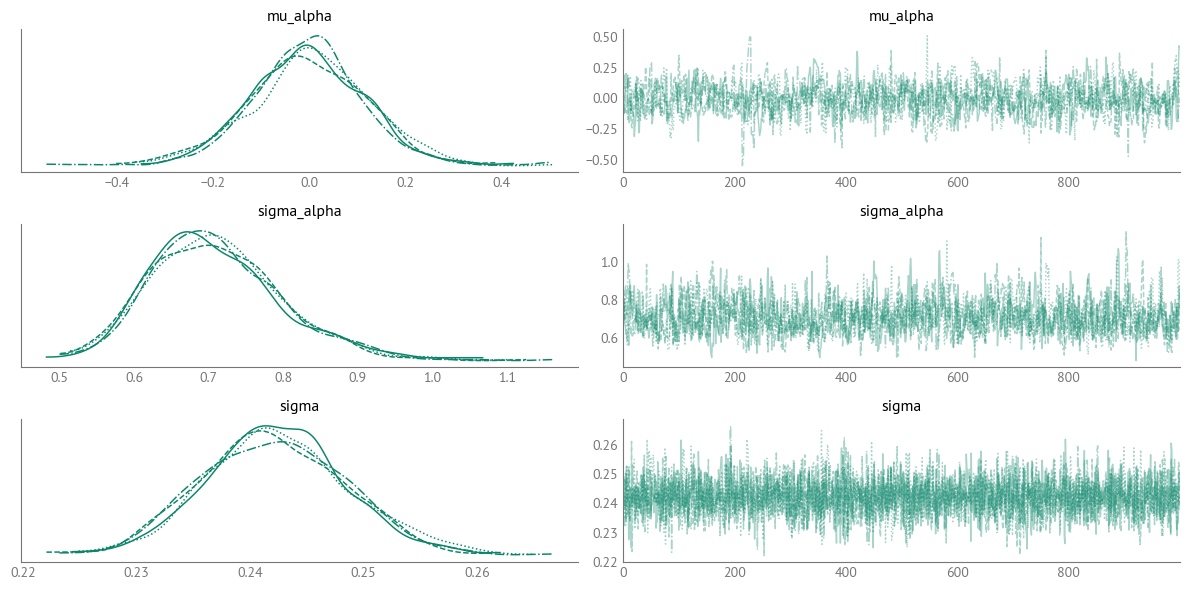

In [38]:
# Plot trace plots for key parameters (HALE)
az.plot_trace(trace_hale, var_names=["mu_alpha", "sigma_alpha", "sigma"], compact=True)
plt.tight_layout()
plt.show()

### Posterior Analysis

Extract and analyze posterior distributions:

In [39]:
# Extract posterior means and credible intervals for beta coefficients (HALE)
beta_summary_hale = az.summary(trace_hale, var_names=["beta"])
beta_summary_hale.index = data_hale["meta"]["predictors"]
beta_summary_hale

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Gap_Alcohol,0.145,0.034,0.081,0.211,0.001,0.001,3899.0,2739.0,1.0
Gap_Suicide,0.424,0.041,0.344,0.500,0.001,0.001,3546.0,2553.0,1.0
Gap_Homicide,0.384,0.022,0.341,0.423,0.000,0.000,5073.0,2827.0,1.0
Gap_RoadTraffic,0.476,0.025,0.426,0.519,0.000,0.000,3681.0,3103.0,1.0
Gap_Cardiovascular,-0.252,0.026,-0.301,-0.204,0.000,0.000,3079.0,2908.0,1.0
Gap_Diabetes,-0.129,0.023,-0.171,-0.084,0.000,0.000,4278.0,3277.0,1.0
Gap_Neoplasms,0.349,0.054,0.251,0.454,0.001,0.001,2558.0,2761.0,1.0
Gap_ChronicRespiratory,0.301,0.037,0.228,0.367,0.001,0.001,4038.0,3025.0,1.0
Gap_LiverDisease,0.209,0.030,0.153,0.266,0.000,0.000,3936.0,2847.0,1.0
Gap_UnintentionalInjury,0.152,0.043,0.069,0.231,0.001,0.001,3454.0,2643.0,1.0


In [40]:
# Write beta coefficients table to HTML
beta_summary_hale_formatted = beta_summary_hale.reset_index().rename(columns={'index': 'Predictor'})
write_html_table(beta_summary_hale_formatted, get_output_filename('jb/tables/beta_coefficients_hale.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

In [41]:
# Compute importance measures on original scale
# Extract posterior samples for beta coefficients
beta_samples_hale = trace_hale.posterior["beta"].values.reshape(-1, len(data_hale["meta"]["predictors"]))

# Get SD values used for standardization
X_std_hale = data_hale["meta"]["X_std"]
predictors_hale = data_hale["meta"]["predictors"]

# Compute importance measure: |β_standardized| × SD_original
importance_samples_hale = np.abs(beta_samples_hale) * X_std_hale[np.newaxis, :]

# Create summary table
importance_summary_hale = pd.DataFrame({
    'Predictor': predictors_hale,
    'SD_original': X_std_hale,
    'Beta_standardized_mean': beta_summary_hale['mean'].values,
    'Beta_standardized_hdi_3%': beta_summary_hale['hdi_3%'].values,
    'Beta_standardized_hdi_97%': beta_summary_hale['hdi_97%'].values,
    'Importance_mean': importance_samples_hale.mean(axis=0),
    'Importance_hdi_3%': np.percentile(importance_samples_hale, 3, axis=0),
    'Importance_hdi_97%': np.percentile(importance_samples_hale, 97, axis=0),
})

# Format for display
importance_summary_hale_formatted = importance_summary_hale.copy()
importance_summary_hale_formatted['Beta_standardized'] = (
    importance_summary_hale['Beta_standardized_mean'].round(3).astype(str) + 
    ' [' + importance_summary_hale['Beta_standardized_hdi_3%'].round(3).astype(str) + 
    ', ' + importance_summary_hale['Beta_standardized_hdi_97%'].round(3).astype(str) + ']'
)
importance_summary_hale_formatted['Importance'] = (
    importance_summary_hale['Importance_mean'].round(3).astype(str) + 
    ' [' + importance_summary_hale['Importance_hdi_3%'].round(3).astype(str) + 
    ', ' + importance_summary_hale['Importance_hdi_97%'].round(3).astype(str) + ']'
)

# Select columns for output table and sort by importance
importance_table_hale = importance_summary_hale_formatted[[
    'Predictor', 'SD_original', 'Beta_standardized', 'Importance'
]].copy()
importance_table_hale = importance_table_hale.loc[
    importance_summary_hale.sort_values('Importance_mean', ascending=False).index
].reset_index(drop=True)

print("Importance Measures on Original Scale (HALE Gap Model):")
print(importance_table_hale.to_string(index=False))

# Write to HTML
write_html_table(importance_table_hale, get_output_filename('jb/tables/importance_measures_hale.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

Importance Measures on Original Scale (HALE Gap Model):
              Predictor  SD_original       Beta_standardized            Importance
          Gap_Neoplasms    38.253573    0.349 [0.251, 0.454] 13.35 [9.367, 17.177]
     Gap_Cardiovascular    36.421918 -0.252 [-0.301, -0.204] 9.193 [7.426, 10.957]
           Gap_Homicide    13.672098    0.384 [0.341, 0.423]  5.249 [4.694, 5.816]
            Gap_Suicide     9.802690      0.424 [0.344, 0.5]  4.158 [3.397, 4.925]
 Gap_ChronicRespiratory    10.674658    0.301 [0.228, 0.367]   3.21 [2.449, 3.946]
        Gap_RoadTraffic     5.907138    0.476 [0.426, 0.519]    2.81 [2.538, 3.09]
Gap_UnintentionalInjury    15.478384    0.152 [0.069, 0.231]   2.36 [1.086, 3.609]
       Gap_LiverDisease     9.796011    0.209 [0.153, 0.266]    2.043 [1.488, 2.6]
            Gap_Alcohol     6.191719    0.145 [0.081, 0.211]  0.895 [0.484, 1.296]
              Gap_COVID    10.830462    0.054 [0.037, 0.072]  0.587 [0.399, 0.778]
           Gap_Diabetes     3.4

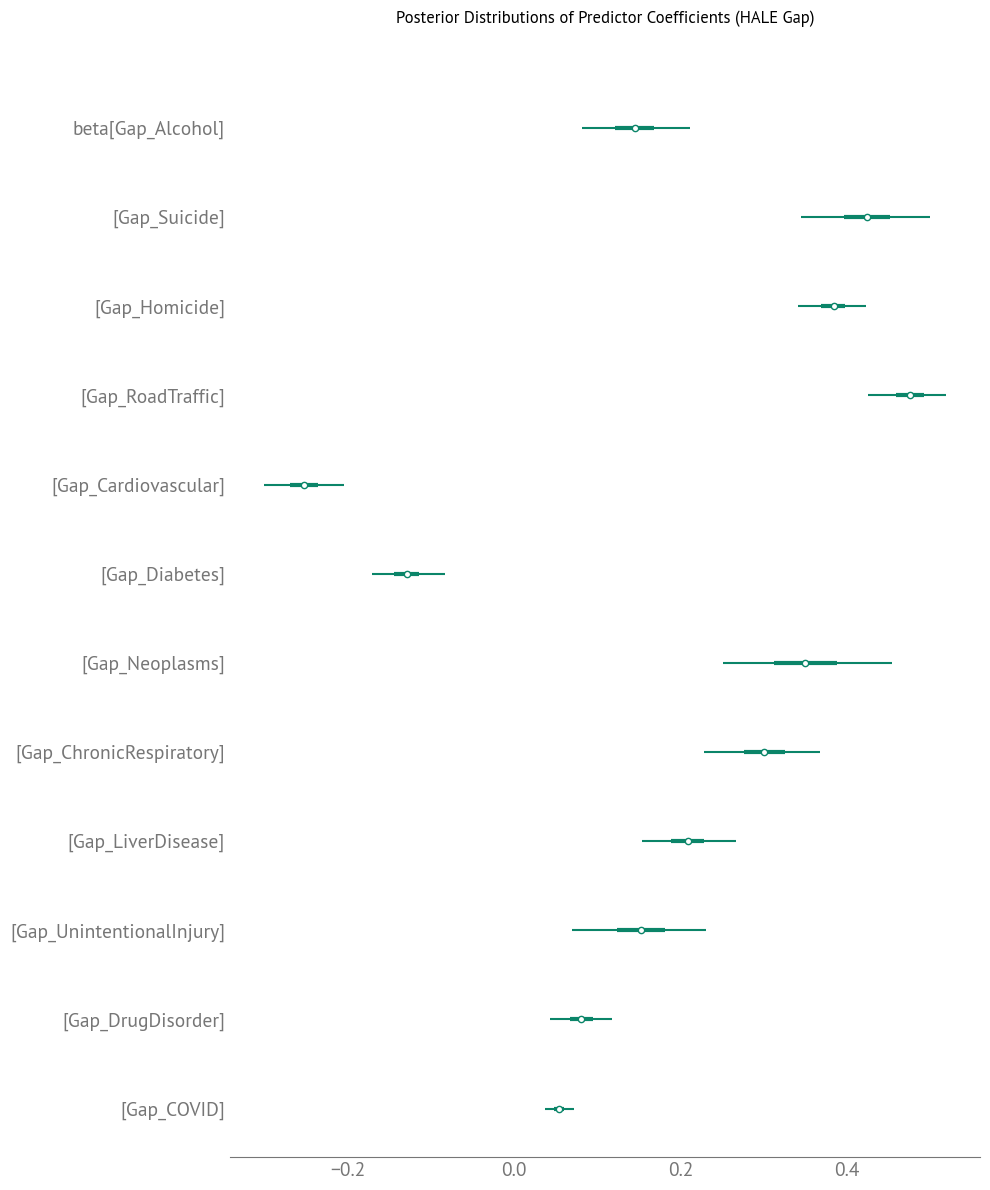

In [42]:
# Plot posterior distributions of beta coefficients (HALE)
az.plot_forest(trace_hale, var_names=["beta"], combined=True, figsize=(10, 12))
plt.title("Posterior Distributions of Predictor Coefficients (HALE Gap)")
plt.tight_layout()
plt.savefig(get_output_filename('jb/figs/posterior_forest_beta_hale.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS), dpi=300, bbox_inches='tight')
plt.show()

In [43]:
# Extract posterior means and credible intervals for alpha coefficients (country intercepts, HALE)
alpha_summary_hale = az.summary(trace_hale, var_names=["alpha"])
alpha_summary_hale.index = data_hale["meta"]["countries"]
alpha_summary_hale

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
AUS,0.062,0.067,-0.062,0.189,0.001,0.001,3980.0,3070.0,1.0
AUT,-0.636,0.073,-0.777,-0.504,0.001,0.001,3763.0,2996.0,1.0
BEL,-1.354,0.085,-1.509,-1.191,0.001,0.001,4115.0,3311.0,1.0
CAN,0.359,0.079,0.213,0.505,0.001,0.001,3003.0,2973.0,1.0
CHE,-0.345,0.063,-0.464,-0.229,0.001,0.001,4185.0,3234.0,1.0
CHL,-0.344,0.092,-0.510,-0.165,0.002,0.001,3156.0,2918.0,1.0
COL,0.268,0.161,-0.055,0.546,0.003,0.002,3088.0,3468.0,1.0
CRI,-0.101,0.107,-0.298,0.101,0.002,0.001,2829.0,3375.0,1.0
CZE,0.513,0.065,0.385,0.630,0.001,0.001,3397.0,3123.0,1.0
DEU,-1.246,0.062,-1.363,-1.131,0.001,0.001,3978.0,3599.0,1.0


In [44]:
# Write alpha coefficients table to HTML
alpha_summary_hale_formatted = alpha_summary_hale.reset_index().rename(columns={'index': 'Country'})
write_html_table(alpha_summary_hale_formatted, get_output_filename('jb/tables/alpha_coefficients_hale.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

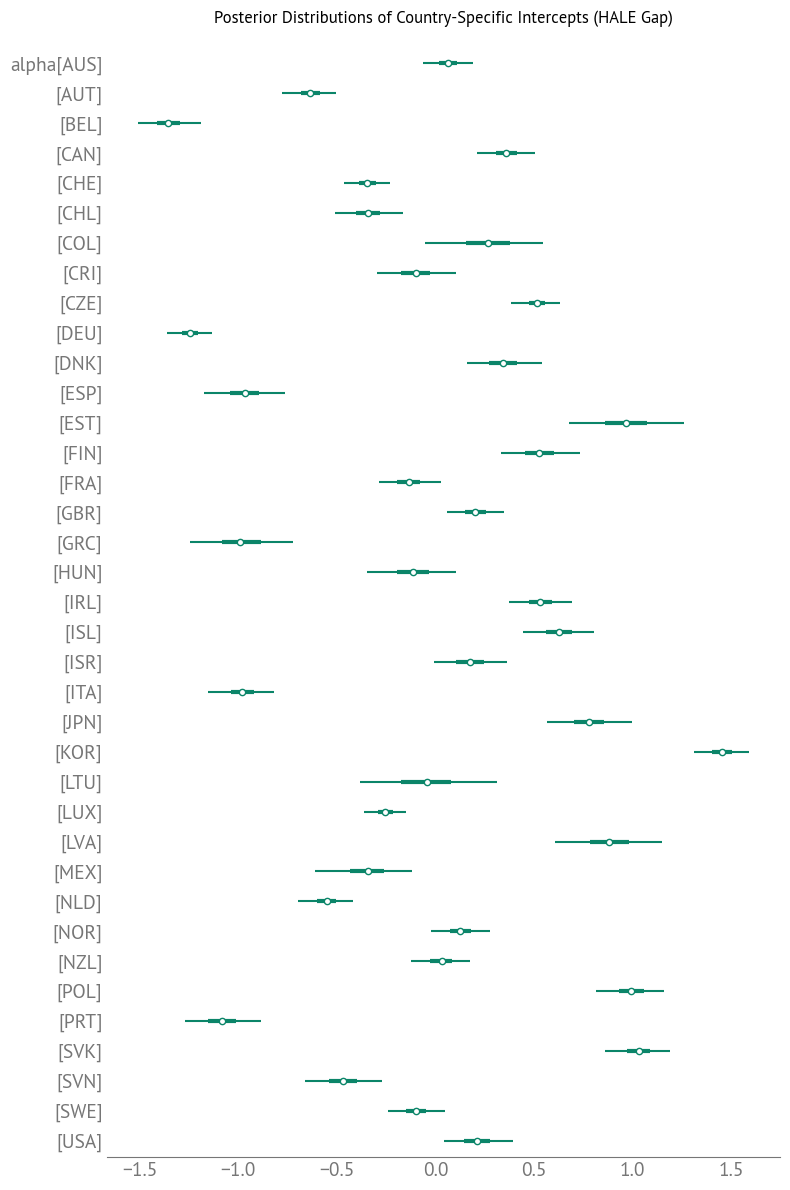

In [45]:
# Plot posterior distributions of country-specific intercepts (alpha) (HALE)
az.plot_forest(trace_hale, var_names=["alpha"], combined=True, figsize=(8, 12))
plt.title("Posterior Distributions of Country-Specific Intercepts (HALE Gap)")
plt.tight_layout()
plt.savefig(get_output_filename('jb/figs/posterior_forest_alpha_hale.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS), dpi=300, bbox_inches='tight')
plt.show()

### Correlations

In [46]:
# Extract posterior samples for beta coefficients (if not already done)
beta_extracted_hale = az.extract(trace_hale)
beta_samples_df_hale = pd.DataFrame(
    beta_extracted_hale['beta'].T,
    columns=data_hale["meta"]["predictors"]
)

# Compute correlation matrix for beta coefficients
beta_corr_hale = beta_samples_df_hale.corr()

# Extract upper triangle (excluding diagonal) and convert to long format
beta_corr_triu = np.triu(beta_corr_hale.values, k=1)
beta_corr_long = []
for i in range(len(beta_corr_hale.index)):
    for j in range(i + 1, len(beta_corr_hale.columns)):
        if not np.isnan(beta_corr_triu[i, j]):
            beta_corr_long.append({
                'Predictor1': beta_corr_hale.index[i],
                'Predictor2': beta_corr_hale.columns[j],
                'Correlation': beta_corr_triu[i, j]
            })

beta_corr_df_hale = pd.DataFrame(beta_corr_long)
beta_corr_df_hale['Abs_Correlation'] = beta_corr_df_hale['Correlation'].abs()
beta_corr_top10_hale = beta_corr_df_hale.nlargest(10, 'Abs_Correlation')[
    ['Predictor1', 'Predictor2', 'Correlation']
].sort_values('Correlation', key=abs, ascending=False)

print("Top 10 correlations among beta coefficients (HALE):")
beta_corr_top10_hale

Top 10 correlations among beta coefficients (HALE):


,Predictor1,Predictor2,Correlation
46,Gap_Diabetes,Gap_ChronicRespiratory,0.468503
51,Gap_Neoplasms,Gap_ChronicRespiratory,-0.408885
18,Gap_Suicide,Gap_UnintentionalInjury,-0.399447
8,Gap_Alcohol,Gap_UnintentionalInjury,-0.396014
42,Gap_Cardiovascular,Gap_UnintentionalInjury,-0.371797
33,Gap_RoadTraffic,Gap_ChronicRespiratory,-0.344703
35,Gap_RoadTraffic,Gap_UnintentionalInjury,-0.315543
12,Gap_Suicide,Gap_RoadTraffic,-0.303726
32,Gap_RoadTraffic,Gap_Neoplasms,0.301070
38,Gap_Cardiovascular,Gap_Diabetes,-0.287256


In [47]:
# Write beta correlations table to HTML
write_html_table(beta_corr_top10_hale, get_output_filename('jb/tables/beta_correlations_top10_hale.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

In [48]:
# Extract posterior samples for alpha coefficients (country intercepts)
alpha_extracted_hale = az.extract(trace_hale)
alpha_samples_df_hale = pd.DataFrame(
    alpha_extracted_hale['alpha'].T,
    columns=data_hale["meta"]["countries"]
)

# Compute correlation matrix for alpha coefficients
alpha_corr_hale = alpha_samples_df_hale.corr()

# Extract upper triangle (excluding diagonal) and convert to long format
alpha_corr_triu = np.triu(alpha_corr_hale.values, k=1)
alpha_corr_long = []
for i in range(len(alpha_corr_hale.index)):
    for j in range(i + 1, len(alpha_corr_hale.columns)):
        if not np.isnan(alpha_corr_triu[i, j]):
            alpha_corr_long.append({
                'Country1': alpha_corr_hale.index[i],
                'Country2': alpha_corr_hale.columns[j],
                'Correlation': alpha_corr_triu[i, j]
            })

alpha_corr_df_hale = pd.DataFrame(alpha_corr_long)
alpha_corr_df_hale['Abs_Correlation'] = alpha_corr_df_hale['Correlation'].abs()
alpha_corr_top10_hale = alpha_corr_df_hale.nlargest(10, 'Abs_Correlation')[
    ['Country1', 'Country2', 'Correlation']
].sort_values('Correlation', key=abs, ascending=False)

print("Top 10 correlations among alpha coefficients (country intercepts, HALE):")
alpha_corr_top10_hale

Top 10 correlations among alpha coefficients (country intercepts, HALE):


,Country1,Country2,Correlation
379,EST,LVA,0.774118
589,LTU,LVA,0.710283
392,FIN,GRC,-0.687299
191,CHL,MEX,0.686686
247,CRI,LTU,-0.684217
377,EST,LTU,0.680332
471,GRC,PRT,0.653421
533,ISR,LTU,-0.651408
350,ESP,ITA,0.650097
201,COL,CRI,0.645603


In [49]:
# Write alpha correlations table to HTML
write_html_table(alpha_corr_top10_hale, get_output_filename('jb/tables/alpha_correlations_top10_hale.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

### Comparison with Cross-Sectional Elastic Net Model

In [50]:
def plot_bayesian_elasticnet_comparison(beta_samples_df, elastic_net_coefs, common_predictors,
                                        title, output_filename, n_rows=5, n_cols=4):
    """
    Create comparison visualization showing posterior distributions vs Elastic Net coefficients.
    
    Parameters
    ----------
    beta_samples_df : pd.DataFrame
        DataFrame with posterior samples (columns = predictors, rows = samples)
    elastic_net_coefs : pd.DataFrame
        DataFrame with Elastic Net coefficients (indexed by predictor)
    common_predictors : list
        List of common predictors between Bayesian and Elastic Net models
    title : str
        Title for the plot
    output_filename : str
        Filename to save the figure
    n_rows : int
        Number of rows in subplot grid (default: 5)
    n_cols : int
        Number of columns in subplot grid (default: 4)
    """
    n_plots = n_rows * n_cols
    
    # Select predictors to plot (prioritize those with non-zero EN coefficients)
    predictors_to_plot = elastic_net_coefs.loc[common_predictors].sort_values(
        'ElasticNet_Coefficient', key=abs, ascending=False
    ).head(n_plots).index.tolist()
    
    # If we have fewer predictors than subplots, use all predictors
    if len(common_predictors) < n_plots:
        predictors_to_plot = common_predictors
        n_rows = int(np.ceil(len(predictors_to_plot) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 20))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()
    
    for i, pred in enumerate(predictors_to_plot):
        ax = axes[i]
        
        # Get posterior samples for this predictor
        posterior_samples = beta_samples_df[pred].values
        
        # Get Elastic Net coefficient
        en_coef = elastic_net_coefs.loc[pred, 'ElasticNet_Coefficient']
        
        # Plot posterior distribution with HDI using az.plot_dist
        az.plot_dist(posterior_samples, ax=ax, color=AIBM_COLORS['crimson'])
        
        # Add vertical line for Elastic Net coefficient
        ax.axvline(en_coef, color=AIBM_COLORS['blue'], linestyle='--', linewidth=2, 
                   label=f'Elastic Net: {en_coef:.3f}')
        
        # Add vertical line for posterior mean
        posterior_mean = posterior_samples.mean()
        ax.axvline(posterior_mean, color=AIBM_COLORS['green'], linestyle='-', linewidth=2,
                   label=f'Posterior mean: {posterior_mean:.3f}')
        
        ax.set_xlabel('Coefficient')
        ax.set_ylabel('Density')
        ax.set_title(pred, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(len(predictors_to_plot), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle(title, fontsize=14, y=0.995)
    plt.tight_layout()
    # Update output filename with suffix
    output_filename_suffixed = get_output_filename(output_filename, MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
    plt.savefig(output_filename_suffixed, dpi=300, bbox_inches='tight')
    plt.show()

In [52]:
# Load Elastic Net coefficients from cross-sectional model
# Note: Elastic Net models may only exist for 2019. If CUTOFF_YEAR != 2019, 
# this comparison may not be available or may need to be skipped.
elastic_net_cutoff_year = 2019  # Use same cutoff year as Bayesian model
elastic_net_coefs_hale = pd.read_csv(f'../data/elasticnet_coefficients_hale_{elastic_net_cutoff_year}.csv')
elastic_net_coefs_hale = elastic_net_coefs_hale.set_index('Predictor')

print(f"Loaded {len(elastic_net_coefs_hale)} Elastic Net coefficients for HALE")
print(f"Bayesian model has {len(data_hale['meta']['predictors'])} predictors")

Loaded 22 Elastic Net coefficients for HALE
Bayesian model has 12 predictors


In [53]:
# Extract posterior samples for beta coefficients
beta_extracted_hale = az.extract(trace_hale)

# Create DataFrame with predictor names
beta_samples_df_hale = pd.DataFrame(
    beta_extracted_hale['beta'].T,
    columns=data_hale["meta"]["predictors"]
)

print(f"Posterior samples shape: {beta_samples_df_hale.shape}")

Posterior samples shape: (4000, 12)


In [54]:
# Match predictors between Bayesian and Elastic Net models
# Find common predictors
common_predictors = set(beta_samples_df_hale.columns) & set(elastic_net_coefs_hale.index)
common_predictors = sorted(list(common_predictors))

print(f"Common predictors: {len(common_predictors)}")
print(f"Predictors only in Bayesian model: {len(set(beta_samples_df_hale.columns) - set(elastic_net_coefs_hale.index))}")
print(f"Predictors only in Elastic Net model: {len(set(elastic_net_coefs_hale.index) - set(beta_samples_df_hale.columns))}")

Common predictors: 11
Predictors only in Bayesian model: 1
Predictors only in Elastic Net model: 11


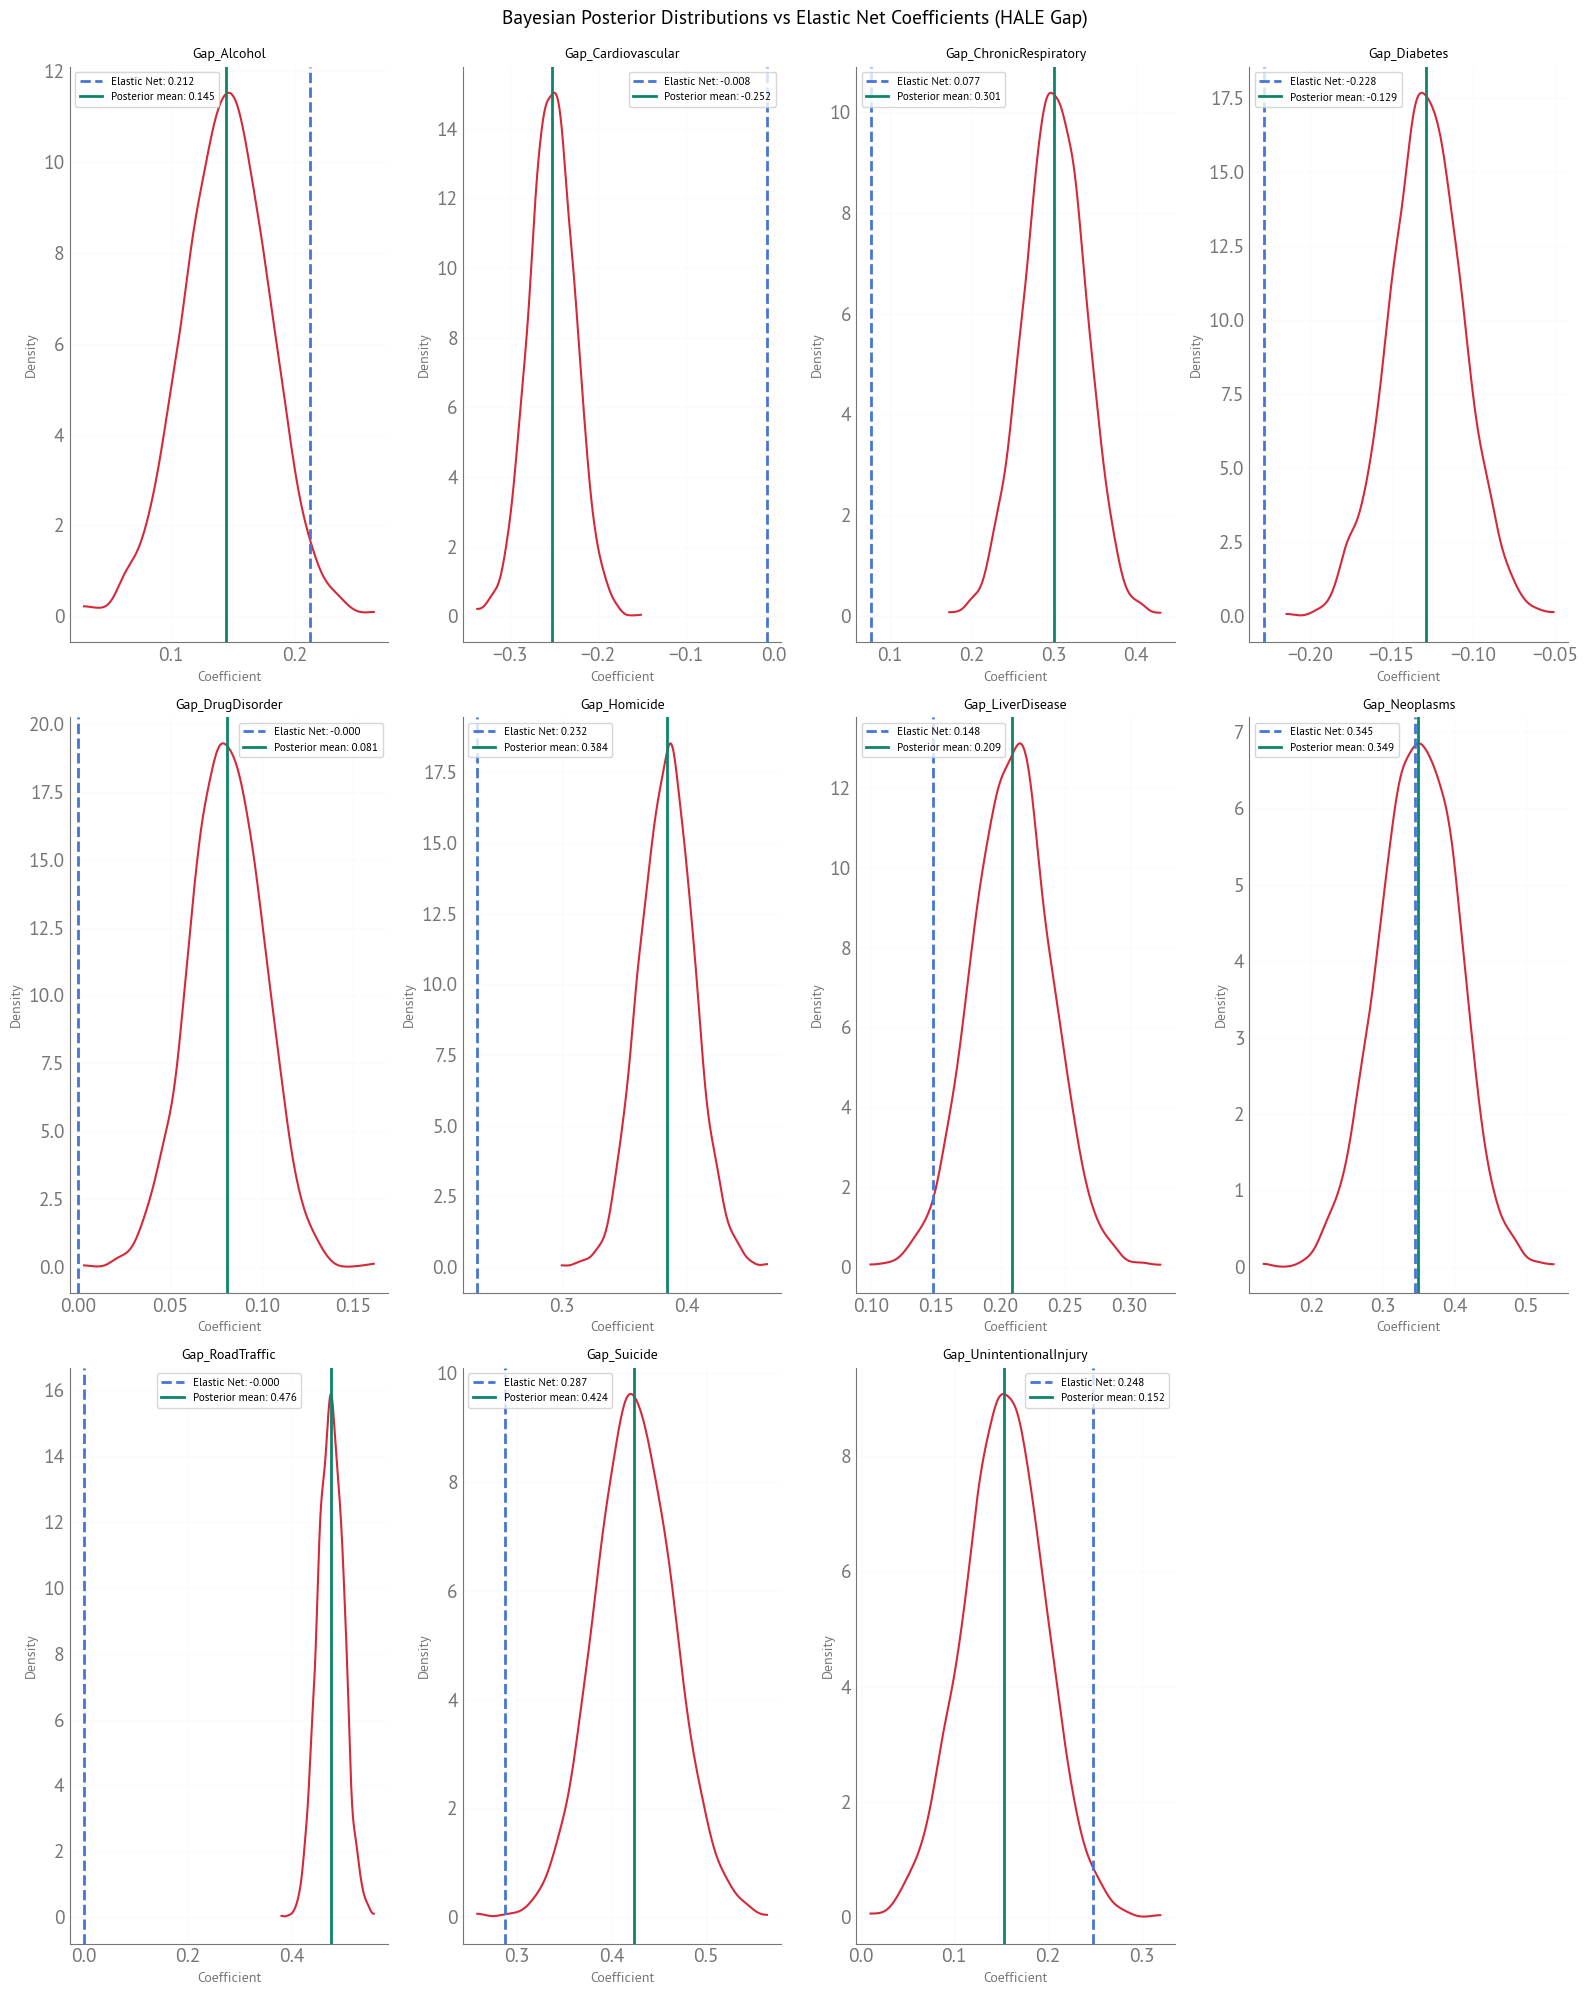

In [55]:
# Create comparison visualization using the function
plot_bayesian_elasticnet_comparison(
    beta_samples_df_hale,
    elastic_net_coefs_hale,
    common_predictors,
    title='Bayesian Posterior Distributions vs Elastic Net Coefficients (HALE Gap)',
    output_filename='jb/figs/bayesian_elasticnet_comparison_hale.png'
)

In [56]:
# Create summary comparison table
comparison_table_hale = pd.DataFrame({
    'Predictor': common_predictors,
    'ElasticNet_Coefficient': [elastic_net_coefs_hale.loc[p, 'ElasticNet_Coefficient'] for p in common_predictors],
    'Bayesian_Mean': [beta_samples_df_hale[p].mean() for p in common_predictors],
    'Bayesian_Std': [beta_samples_df_hale[p].std() for p in common_predictors],
    'Bayesian_CI_Lower': [np.percentile(beta_samples_df_hale[p].values, 2.5) for p in common_predictors],
    'Bayesian_CI_Upper': [np.percentile(beta_samples_df_hale[p].values, 97.5) for p in common_predictors],
    'Difference': [beta_samples_df_hale[p].mean() - elastic_net_coefs_hale.loc[p, 'ElasticNet_Coefficient'] 
                   for p in common_predictors]
})

comparison_table_hale = comparison_table_hale.sort_values('ElasticNet_Coefficient', key=abs, ascending=False)
comparison_table_hale.head(20)

,Predictor,ElasticNet_Coefficient,Bayesian_Mean,Bayesian_Std,Bayesian_CI_Lower,Bayesian_CI_Upper,Difference
7,Gap_Neoplasms,0.344777,0.348976,0.054392,0.240647,0.452067,0.004200
9,Gap_Suicide,0.287401,0.424129,0.041335,0.343978,0.506208,0.136728
10,Gap_UnintentionalInjury,0.247515,0.152493,0.043176,0.067105,0.237025,-0.095022
5,Gap_Homicide,0.231818,0.383890,0.021842,0.341869,0.427086,0.152072
3,Gap_Diabetes,-0.228147,-0.128893,0.022750,-0.175476,-0.084354,0.099254
0,Gap_Alcohol,0.211845,0.144608,0.034479,0.075181,0.211531,-0.067237
6,Gap_LiverDisease,0.147692,0.208554,0.030359,0.149505,0.268077,0.060861
2,Gap_ChronicRespiratory,0.076506,0.300697,0.037219,0.227178,0.372088,0.224190
1,Gap_Cardiovascular,-0.007703,-0.252412,0.025825,-0.303338,-0.201109,-0.244709
4,Gap_DrugDisorder,-0.000000,0.080772,0.019882,0.041366,0.119103,0.080772


## Life Expectancy Gap Model

### Build Model

In [57]:
# Build model for Life Expectancy gap
model_le = build_random_intercept_panel_model(data_le, include_year_effects=INCLUDE_YEAR_EFFECTS)
if INCLUDE_YEAR_EFFECTS:
    print("Year effects (GRW): INCLUDED")
else:
    print("Year effects (GRW): NOT INCLUDED")

Year effects (GRW): NOT INCLUDED


### Sample from Posterior

In [58]:
# Sample from Life Expectancy model
with model_le:
    trace_le = pm.sample(
        nuts_sampler='nutpie'
    )

# Add log-likelihood for WAIC/LOO computation (nutpie doesn't save it by default)
trace_le = add_log_likelihood_to_trace(model_le, trace_le)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.24,127
,2000,0,0.28,95
,2000,0,0.27,63
,2000,0,0.24,63


Output()

### Model Diagnostics

Check convergence and sampling quality:

In [59]:
# Life Expectancy model diagnostics
az.summary(trace_le, var_names=["mu_alpha", "sigma_alpha", "sigma", "beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,-0.002,0.102,-0.186,0.200,0.003,0.002,1018.0,1427.0,1.0
sigma_alpha,0.596,0.078,0.462,0.747,0.003,0.002,857.0,1430.0,1.0
sigma,0.284,0.007,0.271,0.297,0.000,0.000,4419.0,2977.0,1.0
beta[Gap_Alcohol],0.172,0.038,0.102,0.243,0.001,0.001,3801.0,3157.0,1.0
beta[Gap_Suicide],0.479,0.049,0.392,0.572,0.001,0.001,3510.0,2862.0,1.0
beta[Gap_Homicide],0.445,0.026,0.397,0.495,0.000,0.000,4309.0,2619.0,1.0
beta[Gap_RoadTraffic],0.437,0.028,0.390,0.496,0.000,0.000,3703.0,2690.0,1.0
beta[Gap_Cardiovascular],-0.197,0.029,-0.248,-0.137,0.001,0.000,3048.0,2977.0,1.0
beta[Gap_Diabetes],-0.131,0.027,-0.180,-0.081,0.000,0.000,3675.0,3225.0,1.0
beta[Gap_Neoplasms],0.362,0.061,0.254,0.480,0.001,0.001,2410.0,2304.0,1.0


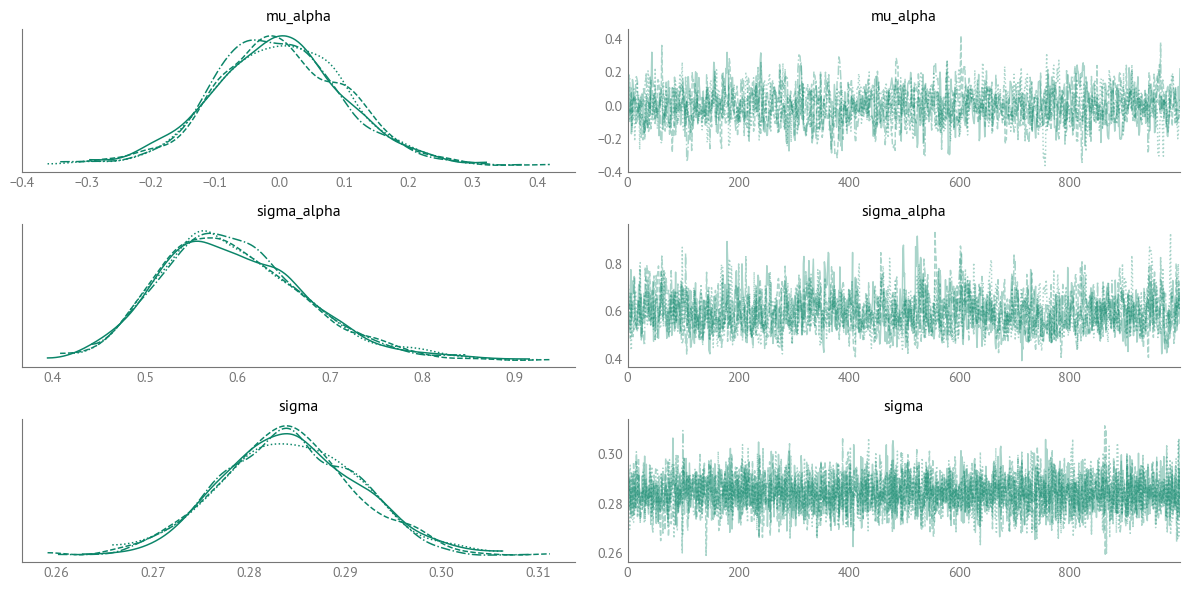

In [60]:
# Plot trace plots for key parameters (Life Expectancy)
az.plot_trace(trace_le, var_names=["mu_alpha", "sigma_alpha", "sigma"], compact=True)
plt.tight_layout()
plt.show()

### Posterior Analysis

Extract and analyze posterior distributions:

In [61]:
# Extract posterior means and credible intervals for beta coefficients (Life Expectancy)
beta_summary_le = az.summary(trace_le, var_names=["beta"])
beta_summary_le.index = data_le["meta"]["predictors"]
beta_summary_le

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Gap_Alcohol,0.172,0.038,0.102,0.243,0.001,0.001,3801.0,3157.0,1.0
Gap_Suicide,0.479,0.049,0.392,0.572,0.001,0.001,3510.0,2862.0,1.0
Gap_Homicide,0.445,0.026,0.397,0.495,0.000,0.000,4309.0,2619.0,1.0
Gap_RoadTraffic,0.437,0.028,0.390,0.496,0.000,0.000,3703.0,2690.0,1.0
Gap_Cardiovascular,-0.197,0.029,-0.248,-0.137,0.001,0.000,3048.0,2977.0,1.0
Gap_Diabetes,-0.131,0.027,-0.180,-0.081,0.000,0.000,3675.0,3225.0,1.0
Gap_Neoplasms,0.362,0.061,0.254,0.480,0.001,0.001,2410.0,2304.0,1.0
Gap_ChronicRespiratory,0.366,0.043,0.287,0.447,0.001,0.001,3208.0,2476.0,1.0
Gap_LiverDisease,0.245,0.035,0.183,0.313,0.001,0.001,3632.0,2647.0,1.0
Gap_UnintentionalInjury,0.122,0.050,0.033,0.218,0.001,0.001,3007.0,2592.0,1.0


In [62]:
# Write beta coefficients table to HTML
beta_summary_le_formatted = beta_summary_le.reset_index().rename(columns={'index': 'Predictor'})
write_html_table(beta_summary_le_formatted, get_output_filename('jb/tables/beta_coefficients_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

In [63]:
# Compute importance measures on original scale
# Extract posterior samples for beta coefficients
beta_samples_le = trace_le.posterior["beta"].values.reshape(-1, len(data_le["meta"]["predictors"]))

# Get SD values used for standardization
X_std_le = data_le["meta"]["X_std"]
predictors_le = data_le["meta"]["predictors"]

# Compute importance measure: |β_standardized| × SD_original
importance_samples_le = np.abs(beta_samples_le) * X_std_le[np.newaxis, :]

# Create summary table
importance_summary_le = pd.DataFrame({
    'Predictor': predictors_le,
    'SD_original': X_std_le,
    'Beta_standardized_mean': beta_summary_le['mean'].values,
    'Beta_standardized_hdi_3%': beta_summary_le['hdi_3%'].values,
    'Beta_standardized_hdi_97%': beta_summary_le['hdi_97%'].values,
    'Importance_mean': importance_samples_le.mean(axis=0),
    'Importance_hdi_3%': np.percentile(importance_samples_le, 3, axis=0),
    'Importance_hdi_97%': np.percentile(importance_samples_le, 97, axis=0),
})

# Format for display
importance_summary_le_formatted = importance_summary_le.copy()
importance_summary_le_formatted['Beta_standardized'] = (
    importance_summary_le['Beta_standardized_mean'].round(3).astype(str) + 
    ' [' + importance_summary_le['Beta_standardized_hdi_3%'].round(3).astype(str) + 
    ', ' + importance_summary_le['Beta_standardized_hdi_97%'].round(3).astype(str) + ']'
)
importance_summary_le_formatted['Importance'] = (
    importance_summary_le['Importance_mean'].round(3).astype(str) + 
    ' [' + importance_summary_le['Importance_hdi_3%'].round(3).astype(str) + 
    ', ' + importance_summary_le['Importance_hdi_97%'].round(3).astype(str) + ']'
)

# Select columns for output table and sort by importance
importance_table_le = importance_summary_le_formatted[[
    'Predictor', 'SD_original', 'Beta_standardized', 'Importance'
]].copy()
importance_table_le = importance_table_le.loc[
    importance_summary_le.sort_values('Importance_mean', ascending=False).index
].reset_index(drop=True)

print("Importance Measures on Original Scale (Life Expectancy Gap Model):")
print(importance_table_le.to_string(index=False))

# Write to HTML
write_html_table(importance_table_le, get_output_filename('jb/tables/importance_measures_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

Importance Measures on Original Scale (Life Expectancy Gap Model):
              Predictor  SD_original       Beta_standardized             Importance
          Gap_Neoplasms    38.253573     0.362 [0.254, 0.48] 13.855 [9.538, 18.176]
     Gap_Cardiovascular    36.421918 -0.197 [-0.248, -0.137]   7.189 [5.138, 9.199]
           Gap_Homicide    13.672098    0.445 [0.397, 0.495]   6.081 [5.406, 6.756]
            Gap_Suicide     9.802690    0.479 [0.392, 0.572]   4.696 [3.814, 5.591]
 Gap_ChronicRespiratory    10.674658    0.366 [0.287, 0.447]   3.906 [3.024, 4.756]
        Gap_RoadTraffic     5.907138     0.437 [0.39, 0.496]   2.584 [2.263, 2.895]
       Gap_LiverDisease     9.796011    0.245 [0.183, 0.313]   2.396 [1.757, 3.032]
Gap_UnintentionalInjury    15.478384    0.122 [0.033, 0.218]   1.894 [0.473, 3.338]
              Gap_COVID    10.830462    0.105 [0.085, 0.125]   1.137 [0.919, 1.354]
            Gap_Alcohol     6.191719    0.172 [0.102, 0.243]   1.068 [0.626, 1.501]
         

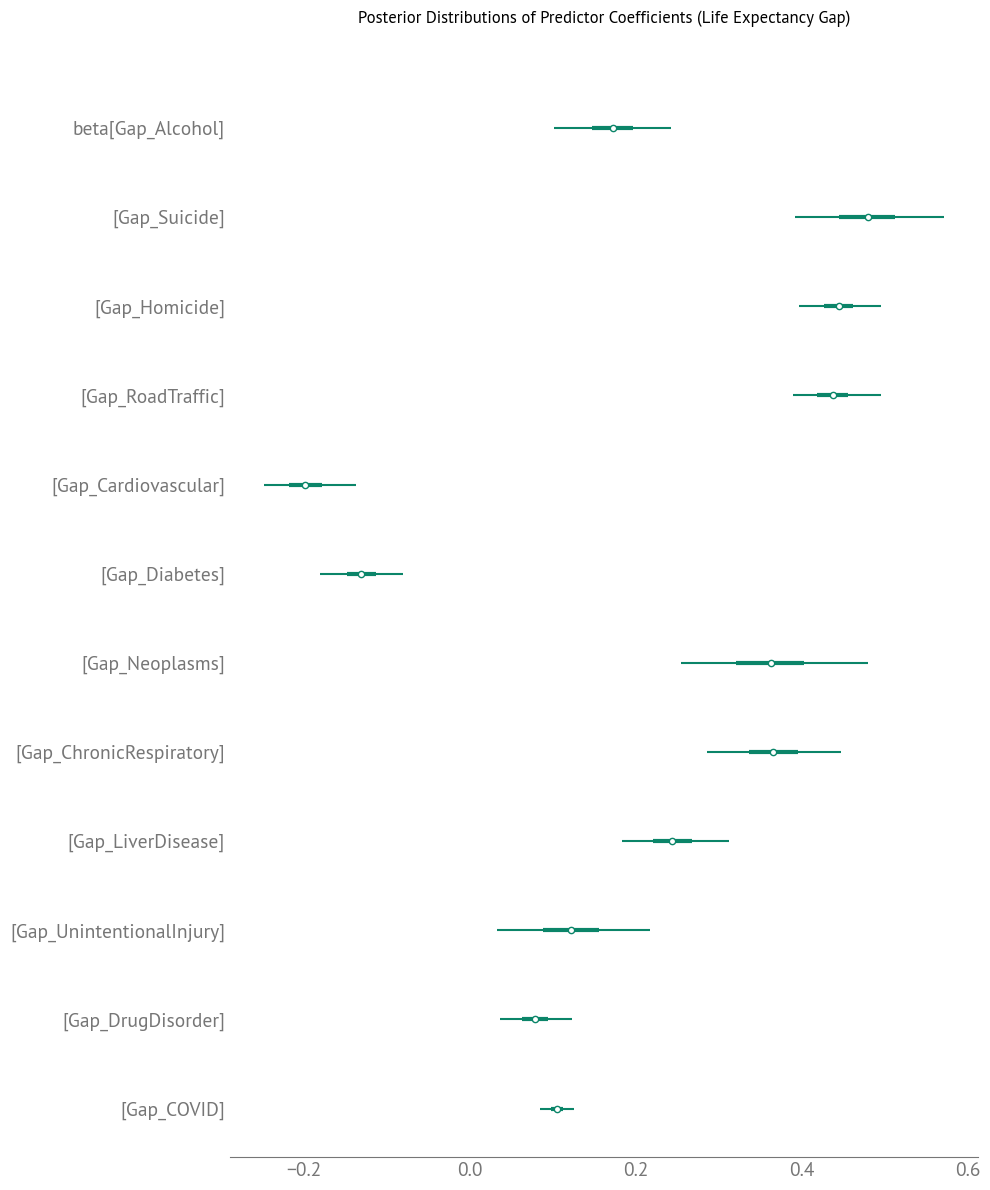

In [64]:
# Plot posterior distributions of beta coefficients (Life Expectancy)
az.plot_forest(trace_le, var_names=["beta"], combined=True, figsize=(10, 12))
plt.title("Posterior Distributions of Predictor Coefficients (Life Expectancy Gap)")
plt.tight_layout()
plt.savefig(get_output_filename('jb/figs/posterior_forest_beta_le.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS), dpi=300, bbox_inches='tight')
plt.show()

In [65]:
# Extract posterior means and credible intervals for alpha coefficients (country intercepts, Life Expectancy)
alpha_summary_le = az.summary(trace_le, var_names=["alpha"])
alpha_summary_le.index = data_le["meta"]["countries"]
alpha_summary_le

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
AUS,-0.167,0.075,-0.320,-0.032,0.001,0.001,3982.0,3441.0,1.0
AUT,-0.520,0.083,-0.671,-0.359,0.001,0.001,3923.0,3613.0,1.0
BEL,-1.077,0.100,-1.261,-0.891,0.002,0.001,3800.0,3741.0,1.0
CAN,0.116,0.090,-0.051,0.284,0.002,0.001,3122.0,2959.0,1.0
CHE,-0.313,0.070,-0.444,-0.186,0.001,0.001,4141.0,3095.0,1.0
CHL,0.128,0.103,-0.059,0.316,0.002,0.001,3246.0,3384.0,1.0
COL,-0.419,0.182,-0.759,-0.077,0.003,0.003,2960.0,3070.0,1.0
CRI,-0.341,0.118,-0.563,-0.127,0.002,0.002,2648.0,2808.0,1.0
CZE,0.040,0.073,-0.105,0.175,0.001,0.001,3854.0,3105.0,1.0
DEU,-0.579,0.072,-0.716,-0.449,0.001,0.001,4527.0,2913.0,1.0


In [66]:
# Write alpha coefficients table to HTML
alpha_summary_le_formatted = alpha_summary_le.reset_index().rename(columns={'index': 'Country'})
write_html_table(alpha_summary_le_formatted, get_output_filename('jb/tables/alpha_coefficients_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

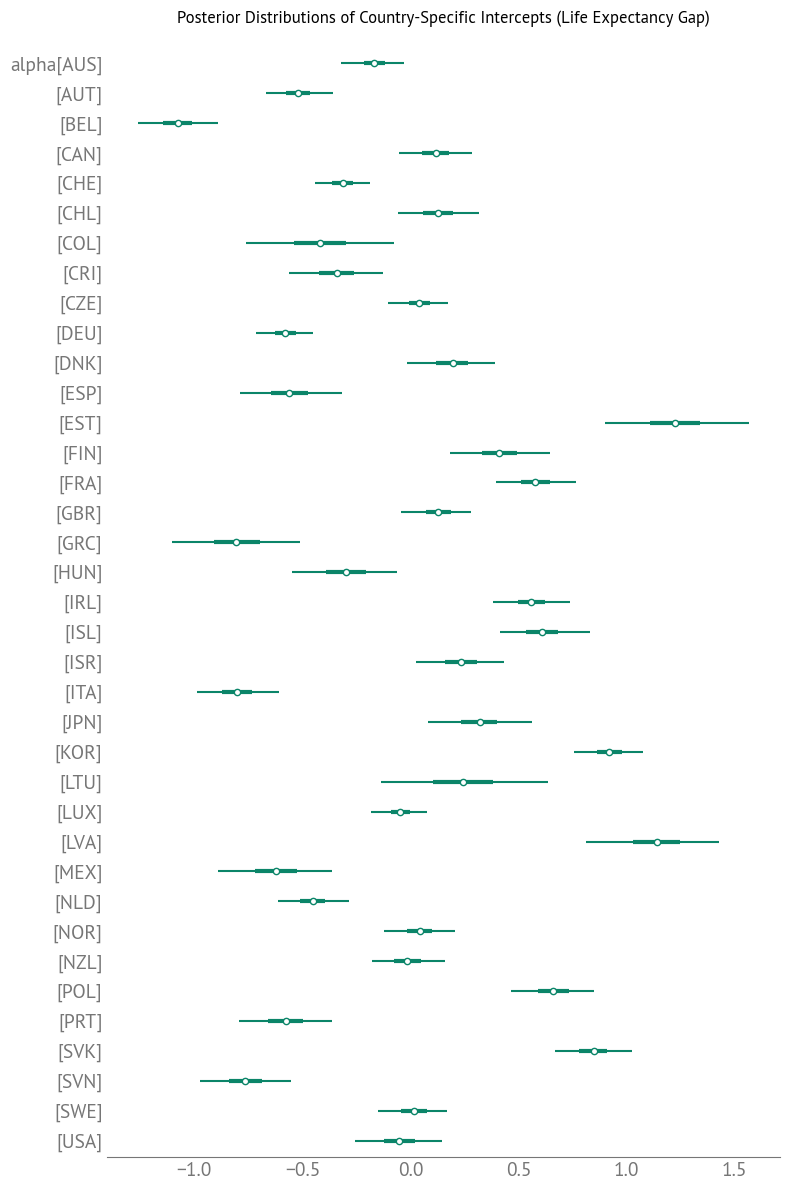

In [67]:
# Plot posterior distributions of country-specific intercepts (alpha) (Life Expectancy)
az.plot_forest(trace_le, var_names=["alpha"], combined=True, figsize=(8, 12))
plt.title("Posterior Distributions of Country-Specific Intercepts (Life Expectancy Gap)")
plt.tight_layout()
plt.savefig(get_output_filename('jb/figs/posterior_forest_alpha_le.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS), dpi=300, bbox_inches='tight')
plt.show()

### Correlations

In [68]:
# Extract posterior samples for beta coefficients (if not already done)
beta_extracted_le = az.extract(trace_le)
beta_samples_df_le = pd.DataFrame(
    beta_extracted_le['beta'].T,
    columns=data_le["meta"]["predictors"]
)

# Compute correlation matrix for beta coefficients
beta_corr_le = beta_samples_df_le.corr()

# Extract upper triangle (excluding diagonal) and convert to long format
beta_corr_triu = np.triu(beta_corr_le.values, k=1)
beta_corr_long = []
for i in range(len(beta_corr_le.index)):
    for j in range(i + 1, len(beta_corr_le.columns)):
        if not np.isnan(beta_corr_triu[i, j]):
            beta_corr_long.append({
                'Predictor1': beta_corr_le.index[i],
                'Predictor2': beta_corr_le.columns[j],
                'Correlation': beta_corr_triu[i, j]
            })

beta_corr_df_le = pd.DataFrame(beta_corr_long)
beta_corr_df_le['Abs_Correlation'] = beta_corr_df_le['Correlation'].abs()
beta_corr_top10_le = beta_corr_df_le.nlargest(10, 'Abs_Correlation')[
    ['Predictor1', 'Predictor2', 'Correlation']
].sort_values('Correlation', key=abs, ascending=False)

print("Top 10 correlations among beta coefficients (Life Expectancy):")
beta_corr_top10_le

Top 10 correlations among beta coefficients (Life Expectancy):


,Predictor1,Predictor2,Correlation
46,Gap_Diabetes,Gap_ChronicRespiratory,0.455951
18,Gap_Suicide,Gap_UnintentionalInjury,-0.412490
51,Gap_Neoplasms,Gap_ChronicRespiratory,-0.408208
42,Gap_Cardiovascular,Gap_UnintentionalInjury,-0.349228
8,Gap_Alcohol,Gap_UnintentionalInjury,-0.328732
32,Gap_RoadTraffic,Gap_Neoplasms,0.320500
35,Gap_RoadTraffic,Gap_UnintentionalInjury,-0.308109
33,Gap_RoadTraffic,Gap_ChronicRespiratory,-0.296749
38,Gap_Cardiovascular,Gap_Diabetes,-0.286840
12,Gap_Suicide,Gap_RoadTraffic,-0.280869


In [69]:
# Write beta correlations table to HTML
write_html_table(beta_corr_top10_le, get_output_filename('jb/tables/beta_correlations_top10_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

In [70]:
# Extract posterior samples for alpha coefficients (country intercepts)
alpha_extracted_le = az.extract(trace_le)
alpha_samples_df_le = pd.DataFrame(
    alpha_extracted_le['alpha'].T,
    columns=data_le["meta"]["countries"]
)

# Compute correlation matrix for alpha coefficients
alpha_corr_le = alpha_samples_df_le.corr()

# Extract upper triangle (excluding diagonal) and convert to long format
alpha_corr_triu = np.triu(alpha_corr_le.values, k=1)
alpha_corr_long = []
for i in range(len(alpha_corr_le.index)):
    for j in range(i + 1, len(alpha_corr_le.columns)):
        if not np.isnan(alpha_corr_triu[i, j]):
            alpha_corr_long.append({
                'Country1': alpha_corr_le.index[i],
                'Country2': alpha_corr_le.columns[j],
                'Correlation': alpha_corr_triu[i, j]
            })

alpha_corr_df_le = pd.DataFrame(alpha_corr_long)
alpha_corr_df_le['Abs_Correlation'] = alpha_corr_df_le['Correlation'].abs()
alpha_corr_top10_le = alpha_corr_df_le.nlargest(10, 'Abs_Correlation')[
    ['Country1', 'Country2', 'Correlation']
].sort_values('Correlation', key=abs, ascending=False)

print("Top 10 correlations among alpha coefficients (country intercepts, Life Expectancy):")
alpha_corr_top10_le

Top 10 correlations among alpha coefficients (country intercepts, Life Expectancy):


,Country1,Country2,Correlation
379,EST,LVA,0.762503
392,FIN,GRC,-0.677588
589,LTU,LVA,0.677041
247,CRI,LTU,-0.655658
191,CHL,MEX,0.651176
471,GRC,PRT,0.647171
377,EST,LTU,0.644588
350,ESP,ITA,0.638548
533,ISR,LTU,-0.609748
201,COL,CRI,0.603857


In [71]:
# Write alpha correlations table to HTML
write_html_table(alpha_corr_top10_le, get_output_filename('jb/tables/alpha_correlations_top10_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

### Comparison with Cross-Sectional Elastic Net Model

In [72]:
# Load Elastic Net coefficients from cross-sectional model
# Note: Elastic Net models may only exist for 2019. If CUTOFF_YEAR != 2019, 
# this comparison may not be available or may need to be skipped.
elastic_net_cutoff_year = 2019  # Use same cutoff year as Bayesian model
elastic_net_coefs_le = pd.read_csv(f'../data/elasticnet_coefficients_le_{elastic_net_cutoff_year}.csv')
elastic_net_coefs_le = elastic_net_coefs_le.set_index('Predictor')

print(f"Loaded {len(elastic_net_coefs_le)} Elastic Net coefficients for Life Expectancy")
print(f"Bayesian model has {len(data_le['meta']['predictors'])} predictors")

Loaded 22 Elastic Net coefficients for Life Expectancy
Bayesian model has 12 predictors


In [73]:
# Extract posterior samples for beta coefficients
beta_extracted_le = az.extract(trace_le)

# Create DataFrame with predictor names
beta_samples_df_le = pd.DataFrame(
    beta_extracted_le['beta'].T,
    columns=data_le["meta"]["predictors"]
)

print(f"Posterior samples shape: {beta_samples_df_le.shape}")

Posterior samples shape: (4000, 12)


In [74]:
# Match predictors between Bayesian and Elastic Net models
# Find common predictors
common_predictors_le = set(beta_samples_df_le.columns) & set(elastic_net_coefs_le.index)
common_predictors_le = sorted(list(common_predictors_le))

print(f"Common predictors: {len(common_predictors_le)}")
print(f"Predictors only in Bayesian model: {len(set(beta_samples_df_le.columns) - set(elastic_net_coefs_le.index))}")
print(f"Predictors only in Elastic Net model: {len(set(elastic_net_coefs_le.index) - set(beta_samples_df_le.columns))}")

Common predictors: 11
Predictors only in Bayesian model: 1
Predictors only in Elastic Net model: 11


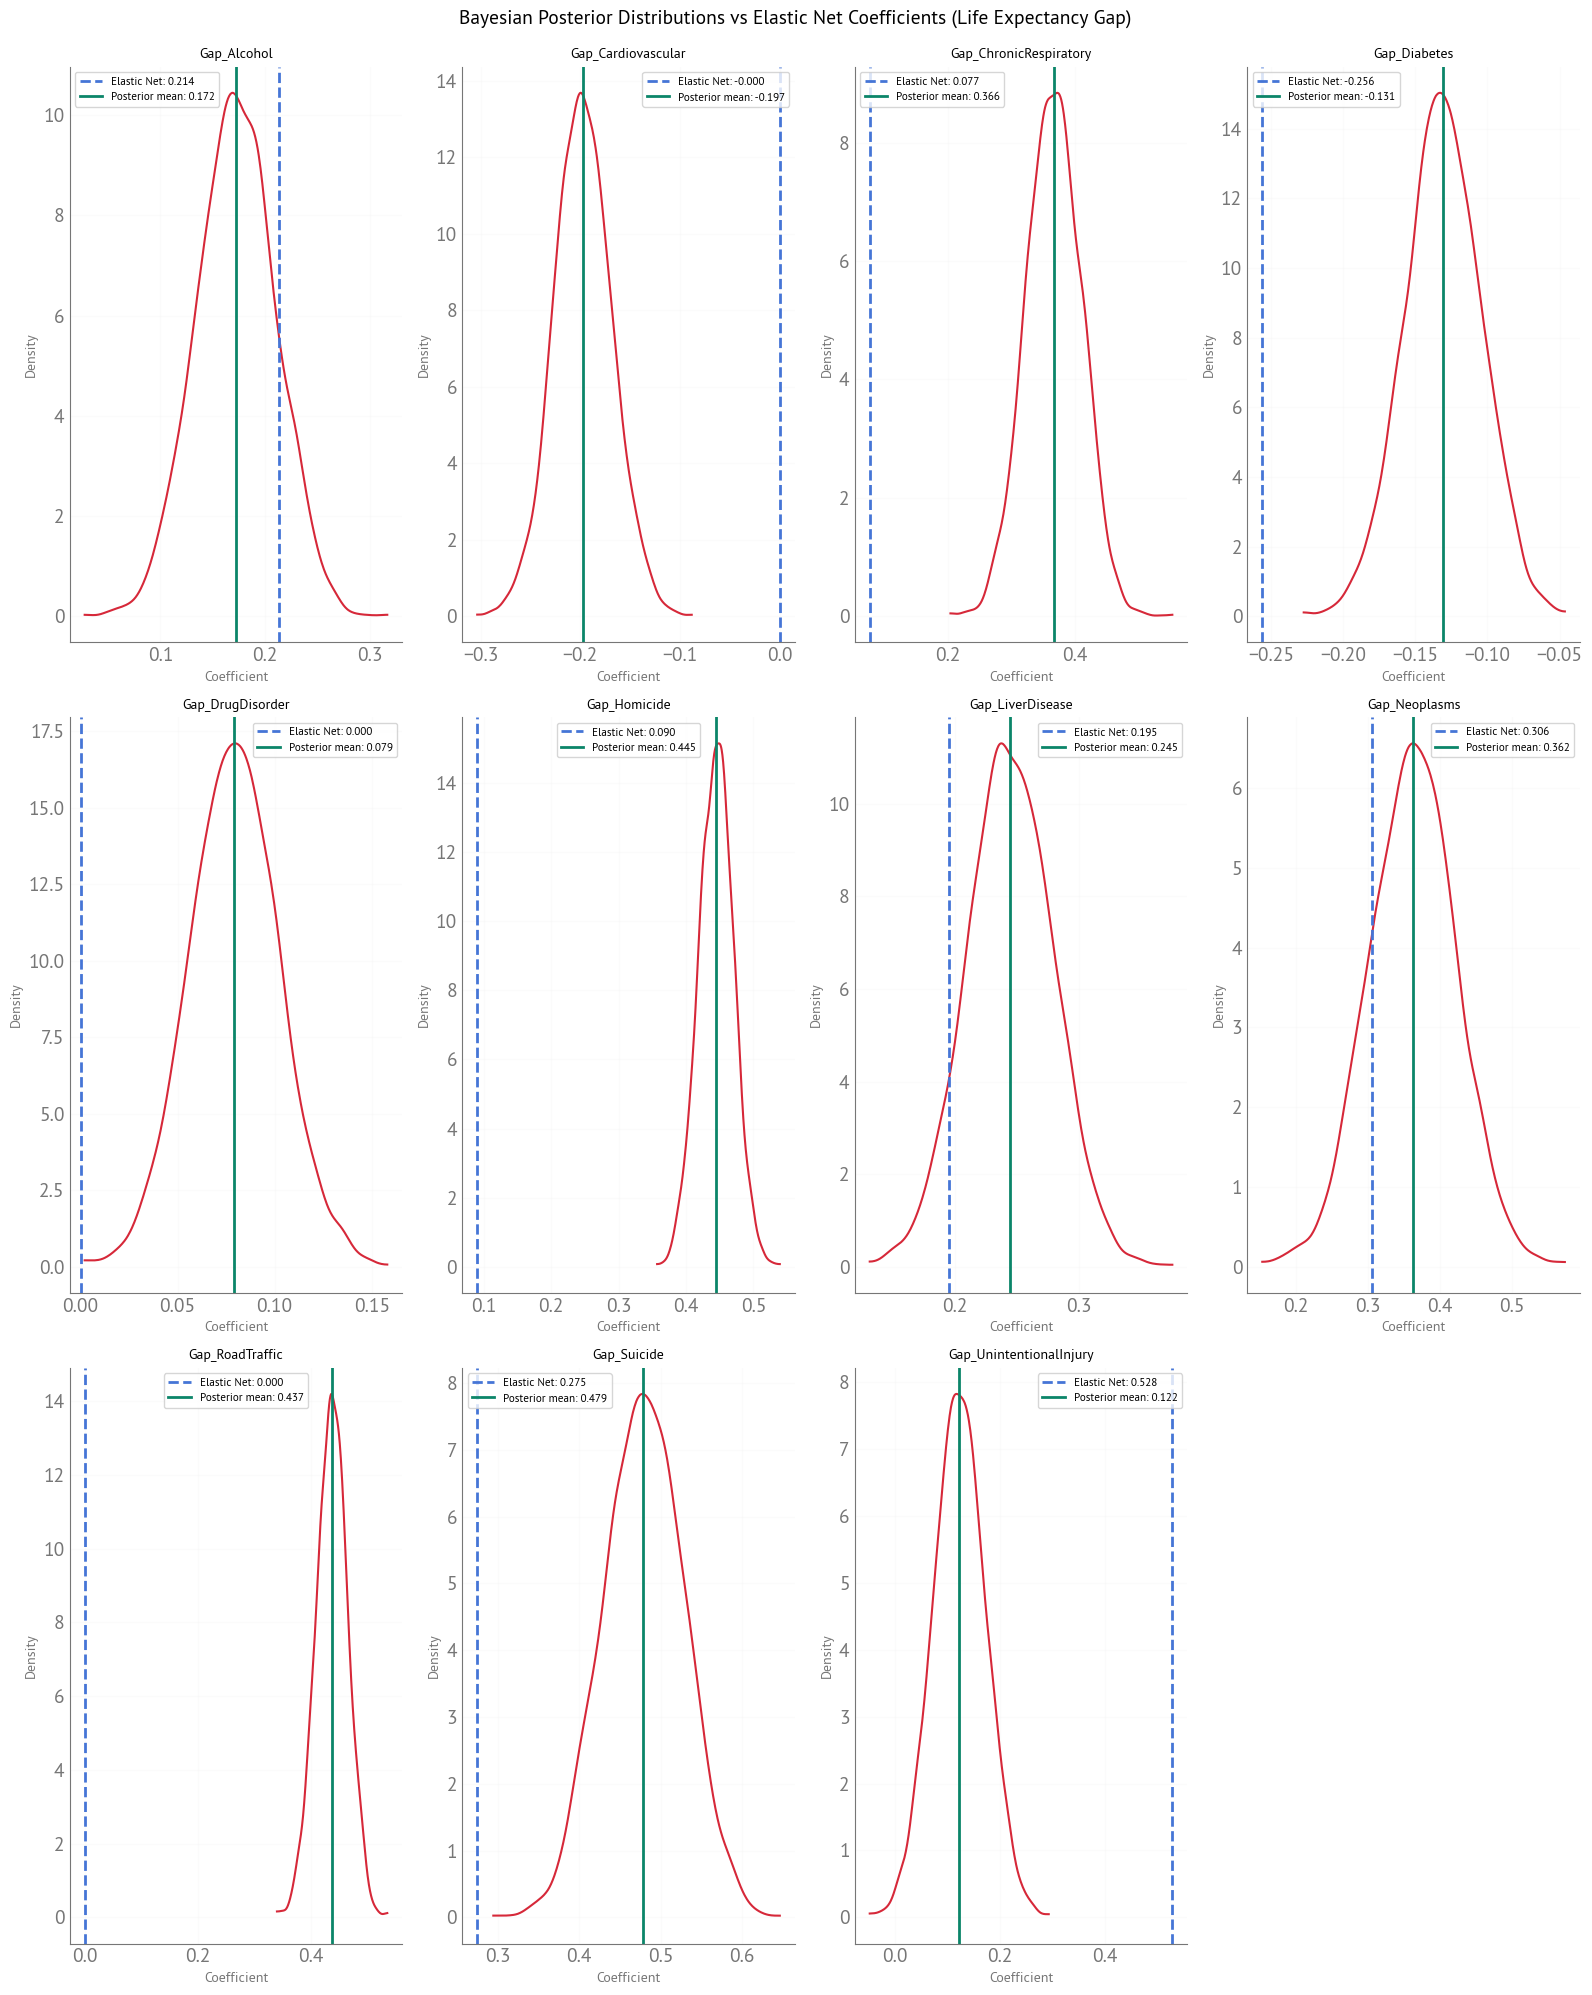

In [75]:
# Create comparison visualization using the function
plot_bayesian_elasticnet_comparison(
    beta_samples_df_le,
    elastic_net_coefs_le,
    common_predictors_le,
    title='Bayesian Posterior Distributions vs Elastic Net Coefficients (Life Expectancy Gap)',
    output_filename='jb/figs/bayesian_elasticnet_comparison_le.png'
)

In [76]:
# Create summary comparison table
comparison_table_le = pd.DataFrame({
    'Predictor': common_predictors_le,
    'ElasticNet_Coefficient': [elastic_net_coefs_le.loc[p, 'ElasticNet_Coefficient'] for p in common_predictors_le],
    'Bayesian_Mean': [beta_samples_df_le[p].mean() for p in common_predictors_le],
    'Bayesian_Std': [beta_samples_df_le[p].std() for p in common_predictors_le],
    'Bayesian_CI_Lower': [np.percentile(beta_samples_df_le[p].values, 2.5) for p in common_predictors_le],
    'Bayesian_CI_Upper': [np.percentile(beta_samples_df_le[p].values, 97.5) for p in common_predictors_le],
    'Difference': [beta_samples_df_le[p].mean() - elastic_net_coefs_le.loc[p, 'ElasticNet_Coefficient'] 
                   for p in common_predictors_le]
})

comparison_table_le = comparison_table_le.sort_values('ElasticNet_Coefficient', key=abs, ascending=False)
comparison_table_le.head(20)

,Predictor,ElasticNet_Coefficient,Bayesian_Mean,Bayesian_Std,Bayesian_CI_Lower,Bayesian_CI_Upper,Difference
10,Gap_UnintentionalInjury,0.528076,0.122142,0.049732,0.025811,0.219041,-0.405933
7,Gap_Neoplasms,0.306021,0.362192,0.060615,0.241276,0.479771,0.056171
9,Gap_Suicide,0.274845,0.479012,0.048812,0.385521,0.575354,0.204166
3,Gap_Diabetes,-0.256190,-0.130894,0.026564,-0.183675,-0.079600,0.125296
0,Gap_Alcohol,0.213706,0.172475,0.037633,0.099129,0.244732,-0.041231
6,Gap_LiverDisease,0.195095,0.244625,0.034744,0.176427,0.312556,0.049530
5,Gap_Homicide,0.090231,0.444788,0.025853,0.393352,0.495512,0.354558
2,Gap_ChronicRespiratory,0.076567,0.365929,0.043356,0.279793,0.448133,0.289362
1,Gap_Cardiovascular,-0.000000,-0.197374,0.029071,-0.254931,-0.138607,-0.197374
4,Gap_DrugDisorder,0.000000,0.079022,0.022923,0.034183,0.124275,0.079022


## Model Evaluation: Posterior Predictive Checks, WAIC, and LOO-CV

### Helper Functions for Model Evaluation

In [77]:
def generate_posterior_predictive_samples(model, trace):
    """
    Generate posterior predictive samples from a PyMC model.
    
    Parameters
    ----------
    model : pymc.Model
        PyMC model object
    trace : arviz.InferenceData
        Posterior trace from MCMC sampling
        
    Returns
    -------
    ppc : arviz.InferenceData
        InferenceData object with posterior predictive samples
    """
    with model:
        ppc = pm.sample_posterior_predictive(trace, extend_inferencedata=True)
    return ppc


def extract_ppc_data(ppc, y_obs):
    """
    Extract and reshape posterior predictive data.
    
    Parameters
    ----------
    ppc : arviz.InferenceData
        InferenceData object with posterior predictive samples
    y_obs : array-like
        Observed data
        
    Returns
    -------
    y_ppc_flat : ndarray
        Flattened posterior predictive samples (chains * draws, obs)
    """
    y_ppc = ppc.posterior_predictive["y_obs"].values
    # Reshape: (chains, draws, obs) -> (chains * draws, obs)
    y_ppc_flat = y_ppc.reshape(-1, y_ppc.shape[-1])
    return y_ppc_flat


def plot_ppc_distributions(ppc, y_obs, y_ppc_flat, title, xlabel, output_filename):
    """
    Plot posterior predictive check: distribution comparison and Q-Q plot.
    
    Parameters
    ----------
    ppc : arviz.InferenceData
        InferenceData object with posterior predictive samples
    y_obs : array-like
        Observed data
    y_ppc_flat : ndarray
        Flattened posterior predictive samples
    title : str
        Title prefix for plots
    xlabel : str
        X-axis label
    output_filename : str
        Filename to save the figure
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Overlay of observed vs posterior predictive distributions
    ax = axes[0]
    az.plot_ppc(ppc, ax=ax, num_pp_samples=100)
    ax.set_title(f"Posterior Predictive Check: Distribution Comparison ({title})")
    ax.set_xlabel(xlabel)
    
    # Plot 2: Q-Q plot comparing observed vs posterior predictive quantiles
    ax = axes[1]
    # Compute quantiles for observed data and all posterior predictive samples (pooled)
    qs = np.linspace(0, 100, 100)
    obs_quantiles = np.percentile(y_obs, qs)
    # Pool all posterior predictive draws and compute quantiles
    ppc_quantiles = np.percentile(y_ppc_flat.ravel(), qs)
    ax.scatter(obs_quantiles, ppc_quantiles, alpha=0.6, color=AIBM_COLORS['crimson'])
    # Add diagonal line
    min_val = min(obs_quantiles.min(), ppc_quantiles.min())
    max_val = max(obs_quantiles.max(), ppc_quantiles.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect fit')
    ax.set_xlabel("Observed Quantiles")
    ax.set_ylabel("Posterior Predictive Quantiles")
    ax.set_title(f"Q-Q Plot: Observed vs Posterior Predictive ({title})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # Update output filename with suffix
    output_filename_suffixed = get_output_filename(output_filename, MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
    plt.savefig(output_filename_suffixed, dpi=300, bbox_inches='tight')
    plt.show()


def plot_ppc_test_statistics(y_obs, y_ppc_flat, output_filename):
    """
    Plot posterior predictive check: test statistics comparison.
    
    Parameters
    ----------
    y_obs : array-like
        Observed data
    y_ppc_flat : ndarray
        Flattened posterior predictive samples
    output_filename : str
        Filename to save the figure
    """
    # Compute test statistics
    obs_mean = y_obs.mean()
    ppc_mean = y_ppc_flat.mean(axis=1)
    
    obs_std = y_obs.std()
    ppc_std = y_ppc_flat.std(axis=1)
    
    obs_min = y_obs.min()
    ppc_min = y_ppc_flat.min(axis=1)
    
    obs_max = y_obs.max()
    ppc_max = y_ppc_flat.max(axis=1)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    test_stats = [
        ("Mean", obs_mean, ppc_mean),
        ("Standard Deviation", obs_std, ppc_std),
        ("Minimum", obs_min, ppc_min),
        ("Maximum", obs_max, ppc_max),
    ]
    
    for i, (name, obs_val, ppc_vals) in enumerate(test_stats):
        ax = axes[i]
        ax.hist(ppc_vals, bins=50, alpha=0.7, color=AIBM_COLORS['blue'], label='Posterior Predictive')
        ax.axvline(obs_val, color=AIBM_COLORS['crimson'], linewidth=2, linestyle='--', 
                   label=f'Observed: {obs_val:.3f}')
        # Compute p-value (proportion of ppc values more extreme than observed)
        p_value = np.mean(np.abs(ppc_vals - ppc_vals.mean()) >= np.abs(obs_val - ppc_vals.mean()))
        ax.set_xlabel(name)
        ax.set_ylabel('Density')
        ax.set_title(f'{name} Test Statistic\n(p-value: {p_value:.3f})')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # Update output filename with suffix
    output_filename_suffixed = get_output_filename(output_filename, MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
    plt.savefig(output_filename_suffixed, dpi=300, bbox_inches='tight')
    plt.show()


def compute_model_metrics(model, trace, model_name):
    """
    Compute WAIC and LOO-CV metrics for a model.
    
    Parameters
    ----------
    model : pymc.Model
        PyMC model object
    trace : arviz.InferenceData
        Posterior trace from MCMC sampling
    model_name : str
        Name of the model (for printing)
        
    Returns
    -------
    waic : arviz.Waic
        WAIC object
    loo : arviz.Loo
        LOO object
    """
    with model:
        waic = az.waic(trace, pointwise=True)  # elpd_waic
        loo = az.loo(trace, pointwise=True)    # elpd_loo
    
    waic_elpd = waic.elpd_waic
    loo_elpd = loo.elpd_loo
    
    print(f"{model_name} - Model Comparison Metrics:")
    print(f"WAIC (ELPD): {waic_elpd:.2f} (SE: {waic.se:.2f})")
    print(f"LOO (ELPD):  {loo_elpd:.2f} (SE: {loo.se:.2f})")
    print(f"\nEffective number of parameters:")
    print(f"  WAIC p_waic: {waic.p_waic:.2f}")
    print(f"  LOO  p_loo:  {loo.p_loo:.2f}")
    
    return waic, loo


def plot_waic_loo(waic, loo, model_name, output_filename):
    """
    Plot WAIC and LOO pointwise contributions.
    
    Parameters
    ----------
    waic : arviz.Waic
        WAIC object
    loo : arviz.Loo
        LOO object
    model_name : str
        Name of the model (for plot titles)
    output_filename : str
        Filename to save the figure
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # WAIC pointwise
    ax = axes[0]
    ax.scatter(range(len(waic.waic_i)), waic.waic_i, alpha=0.6, color=AIBM_COLORS['crimson'])
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.set_xlabel("Observation Index")
    ax.set_ylabel("Pointwise WAIC Contribution")
    ax.set_title(f"Pointwise WAIC Contributions ({model_name})")
    ax.grid(True, alpha=0.3)
    
    # LOO pointwise
    ax = axes[1]
    ax.scatter(range(len(loo.loo_i)), loo.loo_i, alpha=0.6, color=AIBM_COLORS['blue'])
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.set_xlabel("Observation Index")
    ax.set_ylabel("Pointwise LOO Contribution")
    ax.set_title(f"Pointwise LOO Contributions ({model_name})")
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # Update output filename with suffix
    output_filename_suffixed = get_output_filename(output_filename, MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
    plt.savefig(output_filename_suffixed, dpi=300, bbox_inches='tight')
    plt.show()


def check_pareto_k(loo, data, model_name, threshold=0.7):
    """
    Check Pareto k values to identify problematic observations.
    
    Pareto k > 0.7 indicates potentially problematic observations where
    LOO-CV may be unreliable.
    
    Parameters
    ----------
    loo : arviz.Loo
        LOO object
    data : dict
        Data dictionary from prepare_panel_data
    model_name : str
        Name of the model (for printing)
    threshold : float
        Threshold for problematic observations (default: 0.7)
        
    Returns
    -------
    problematic : pandas.DataFrame
        DataFrame with observations having Pareto k > threshold
    """
    pareto_k = loo.pareto_k
    
    # Find problematic observations
    problematic_mask = pareto_k > threshold
    n_problematic = problematic_mask.sum()
    
    print(f"\nPareto k diagnostics ({model_name}):")
    print(f"  Observations with k > {threshold}: {n_problematic} ({100*n_problematic/len(pareto_k):.1f}%)")
    print(f"  Maximum Pareto k: {pareto_k.max():.3f}")
    print(f"  Mean Pareto k: {pareto_k.mean():.3f}")
    print(f"  Median Pareto k: {np.median(pareto_k):.3f}")
    
    if n_problematic > 0:
        problematic_df = pd.DataFrame({
            'Observation': np.where(problematic_mask)[0],
            'Pareto_k': pareto_k[problematic_mask],
            'Country': [data["meta"]["countries"][data["country_idx"][i]] 
                       for i in np.where(problematic_mask)[0]],
            'Year': [data["meta"]["years"][data["year_idx"][i]] 
                    for i in np.where(problematic_mask)[0]]
        })
        problematic_df = problematic_df.sort_values('Pareto_k', ascending=False)
        print(f"\n  Top problematic observations (k > {threshold}):")
        print(problematic_df.head(10).to_string(index=False))
        return problematic_df
    else:
        print(f"  No observations exceed threshold (k > {threshold})")
        return pd.DataFrame()


def identify_influential_observations(loo, data, model_name, output_filename, top_n=10):
    """
    Identify observations with high influence (high |LOO contribution|).
    
    Parameters
    ----------
    loo : arviz.Loo
        LOO object
    data : dict
        Data dictionary from prepare_panel_data
    model_name : str
        Name of the model (for printing)
    output_filename : str
        Filename to save HTML table
    top_n : int
        Number of top influential observations to return (default: 10)
        
    Returns
    -------
    top_influential : pandas.DataFrame
        DataFrame with top influential observations
    """
    loo_i_df = pd.DataFrame({
        'Observation': range(len(loo.loo_i)),
        'LOO_i': loo.loo_i,
        'Abs_LOO_i': np.abs(loo.loo_i),
        'Pareto_k': loo.pareto_k
    })
    
    # Get top N most influential observations
    top_influential = loo_i_df.nlargest(top_n, 'Abs_LOO_i')
    print(f"Top {top_n} most influential observations ({model_name}):")
    print(top_influential)
    
    # Add country and year information
    top_influential['Country'] = [data["meta"]["countries"][data["country_idx"][i]] 
                                  for i in top_influential['Observation']]
    top_influential['Year'] = [data["meta"]["years"][data["year_idx"][i]] 
                              for i in top_influential['Observation']]
    
    # Write to HTML table (update filename with suffix)
    output_filename_suffixed = get_output_filename(output_filename, MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
    write_html_table(
        top_influential[['Country', 'Year', 'LOO_i', 'Pareto_k']].rename(
            columns={'LOO_i': 'LOO Contribution', 'Pareto_k': 'Pareto k'}
        ),
        output_filename_suffixed
    )
    
    return top_influential[['Observation', 'Country', 'Year', 'LOO_i', 'Abs_LOO_i', 'Pareto_k']]

### HALE Gap Model Evaluation

#### Posterior Predictive Checks

Posterior predictive checks compare observed data to data simulated from the posterior distribution to assess model fit.

In [78]:
# Generate posterior predictive samples for HALE model
ppc_hale = generate_posterior_predictive_samples(model_hale, trace_hale)

Sampling: [y_obs]


Output()

In [79]:
# Extract observed and posterior predictive data
y_obs_hale = data_hale["y_centered"]
y_ppc_hale_flat = extract_ppc_data(ppc_hale, y_obs_hale)

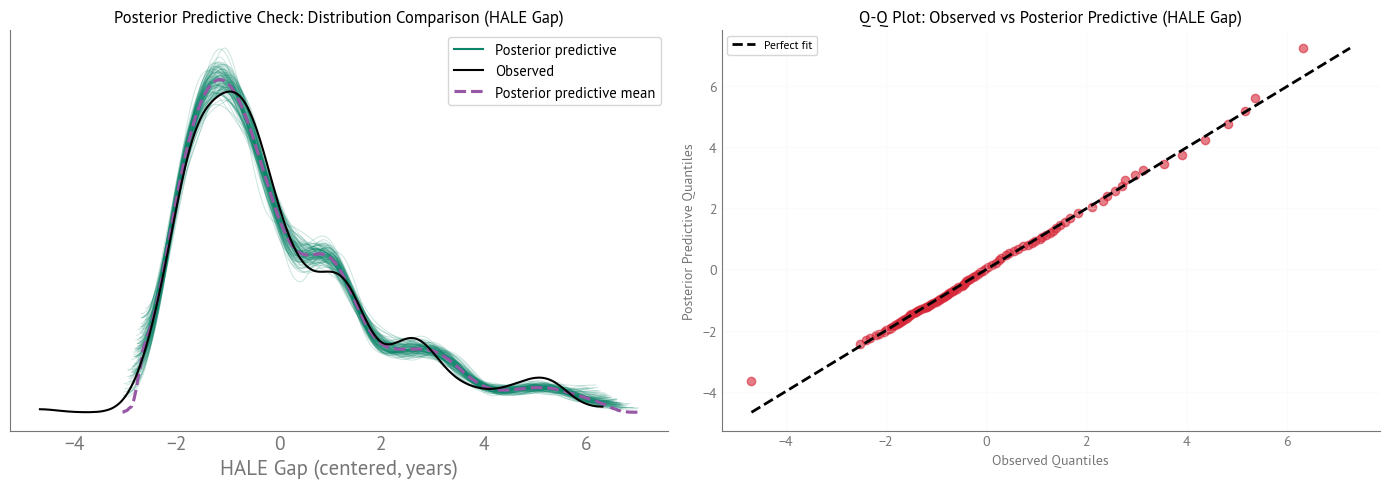

In [80]:
# Plot posterior predictive check: distribution comparison and Q-Q plot
plot_ppc_distributions(
    ppc_hale, y_obs_hale, y_ppc_hale_flat,
    title="HALE Gap",
    xlabel="HALE Gap (centered, years)",
    output_filename='jb/figs/ppc_hale.png'
)

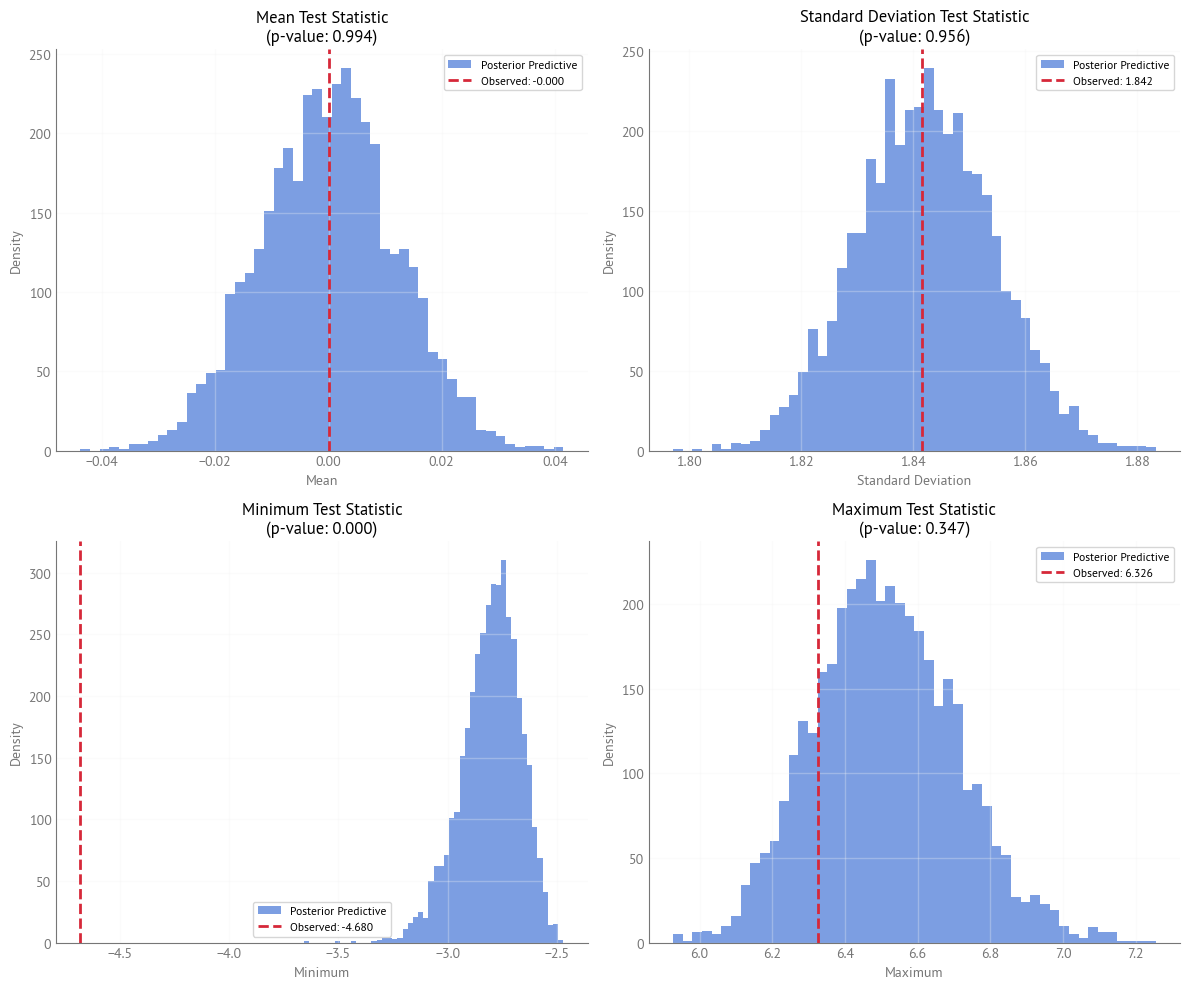

In [81]:
# Posterior predictive check: test statistics
plot_ppc_test_statistics(
    y_obs_hale, y_ppc_hale_flat,
    output_filename='jb/figs/ppc_test_stats_hale.png'
)

#### WAIC and LOO-CV

Compute Widely Applicable Information Criterion (WAIC) and Leave-One-Out Cross-Validation (LOO-CV) to assess model fit and compare models.

In [82]:
# Compute WAIC and LOO-CV for HALE model
waic_hale, loo_hale = compute_model_metrics(model_hale, trace_hale, "HALE Gap Model")

/home/downey/miniconda3/envs/EqualityWEF/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


HALE Gap Model - Model Comparison Metrics:
WAIC (ELPD): -38.07 (SE: 77.43)
LOO (ELPD):  -36.77 (SE: 75.40)

Effective number of parameters:
  WAIC p_waic: 66.52
  LOO  p_loo:  65.22


/home/downey/miniconda3/envs/EqualityWEF/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


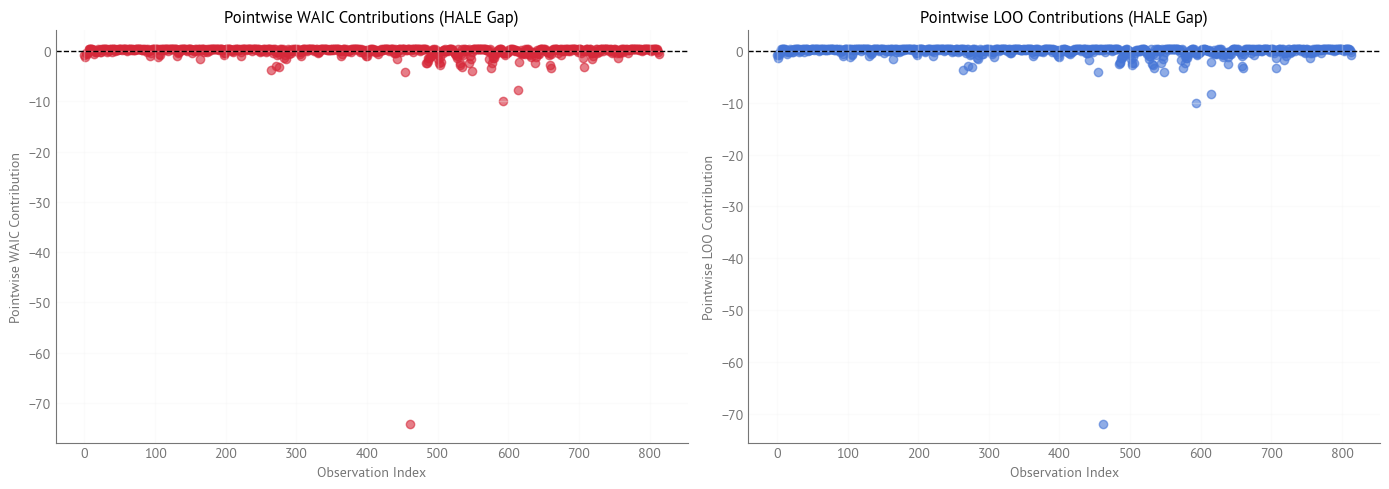

In [83]:
# Plot WAIC and LOO pointwise contributions
plot_waic_loo(
    waic_hale, loo_hale,
    model_name="HALE Gap",
    output_filename='jb/figs/waic_loo_hale.png'
)

In [84]:
# Check Pareto k values for problematic observations
problematic_hale = check_pareto_k(loo_hale, data_hale, model_name="HALE Gap")


Pareto k diagnostics (HALE Gap):
  Observations with k > 0.7: <xarray.DataArray 'pareto_shape' ()> Size: 8B
array(2) (0.2%)
  Maximum Pareto k: 1.664
  Mean Pareto k: 0.098
  Median Pareto k: 0.093

  Top problematic observations (k > 0.7):
 Observation  Pareto_k Country  Year
         461  1.663900     ISR  2021
         614  0.997577     MEX  2020


In [85]:
# Identify observations with high influence (high |LOO contribution|)
top_influential_hale = identify_influential_observations(
    loo_hale, data_hale,
    model_name="HALE Gap",
    output_filename='jb/tables/influential_observations_hale.html'
)
top_influential_hale

Top 10 most influential observations (HALE Gap):
     Observation      LOO_i  Abs_LOO_i  Pareto_k
461          461 -71.947012  71.947012  1.663900
593          593 -10.040405  10.040405  0.691856
614          614  -8.213496   8.213496  0.997577
454          454  -4.117955   4.117955 -0.092494
548          548  -4.031688   4.031688  0.381504
264          264  -3.730392   3.730392  0.234333
575          575  -3.331269   3.331269  0.247794
660          660  -3.304081   3.304081  0.299626
534          534  -3.250314   3.250314  0.382265
707          707  -3.215886   3.215886  0.243131


,Observation,Country,Year,LOO_i,Abs_LOO_i,Pareto_k
461,461,ISR,2021,-71.947012,71.947012,1.663900
593,593,LVA,2021,-10.040405,10.040405,0.691856
614,614,MEX,2020,-8.213496,8.213496,0.997577
454,454,ISR,2014,-4.117955,4.117955,-0.092494
548,548,LTU,2020,-4.031688,4.031688,0.381504
264,264,EST,2000,-3.730392,3.730392,0.234333
575,575,LVA,2003,-3.331269,3.331269,0.247794
660,660,NZL,2000,-3.304081,3.304081,0.299626
534,534,LTU,2006,-3.250314,3.250314,0.382265
707,707,PRT,2003,-3.215886,3.215886,0.243131


### Life Expectancy Gap Model Evaluation

#### Posterior Predictive Checks

In [86]:
# Generate posterior predictive samples for Life Expectancy model
ppc_le = generate_posterior_predictive_samples(model_le, trace_le)

Sampling: [y_obs]


Output()

In [87]:
# Extract observed and posterior predictive data
y_obs_le = data_le["y_centered"]
y_ppc_le_flat = extract_ppc_data(ppc_le, y_obs_le)

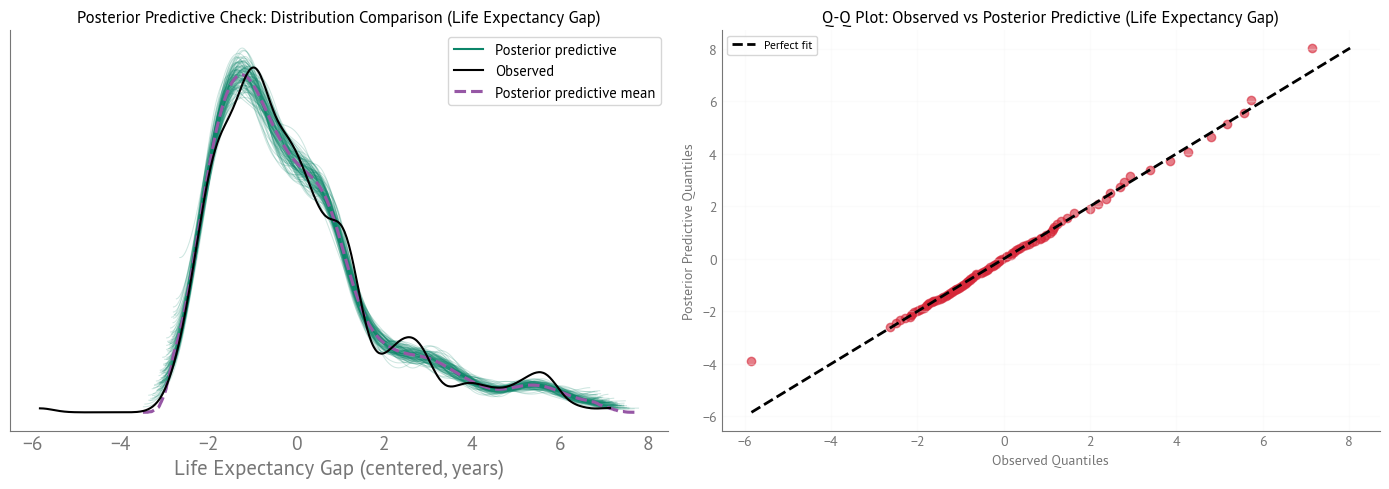

In [88]:
# Plot posterior predictive check: distribution comparison and Q-Q plot
plot_ppc_distributions(
    ppc_le, y_obs_le, y_ppc_le_flat,
    title="Life Expectancy Gap",
    xlabel="Life Expectancy Gap (centered, years)",
    output_filename='jb/figs/ppc_le.png'
)

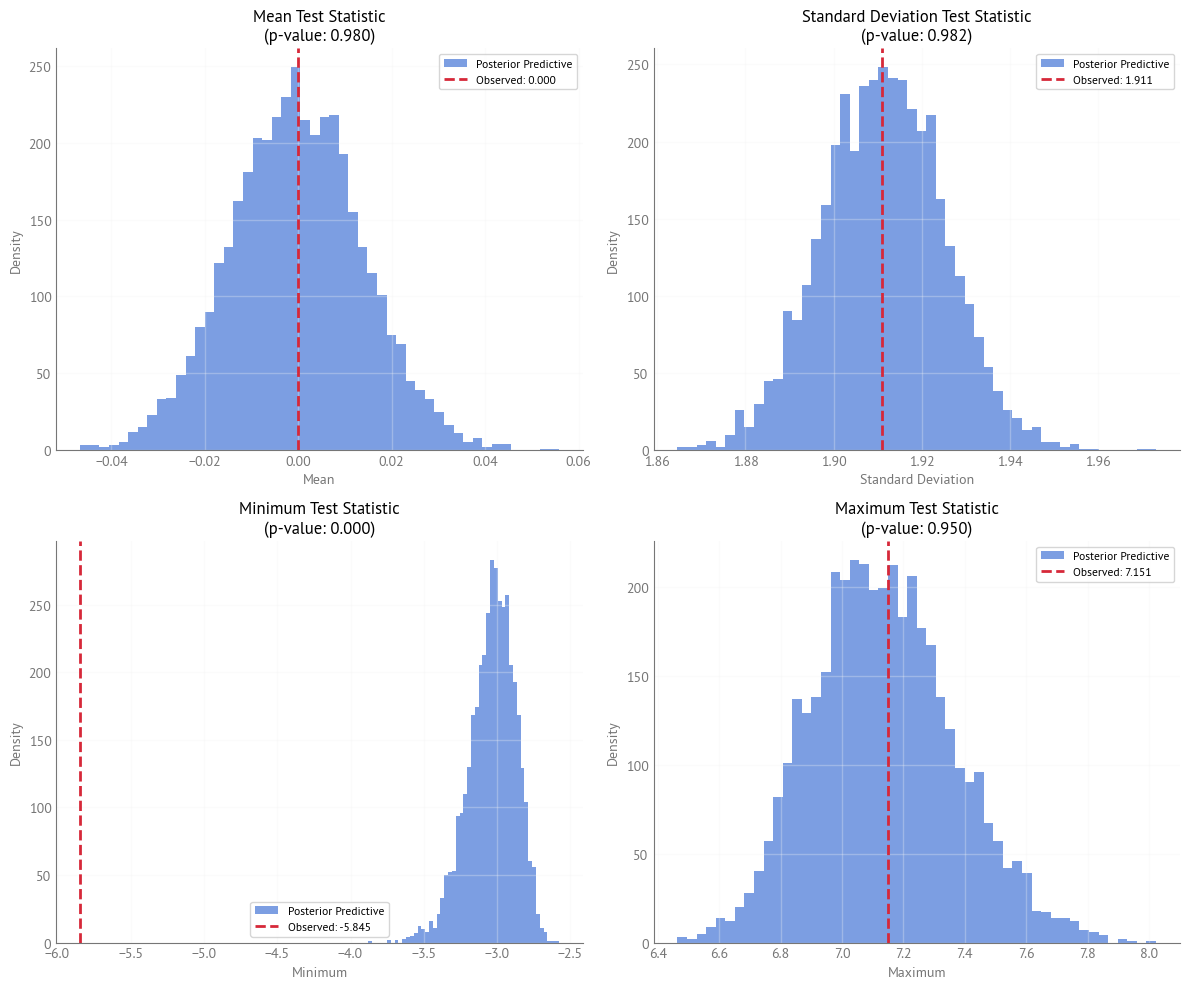

In [89]:
# Posterior predictive check: test statistics
plot_ppc_test_statistics(
    y_obs_le, y_ppc_le_flat,
    output_filename='jb/figs/ppc_test_stats_le.png'
)

#### WAIC and LOO-CV

In [90]:
# Compute WAIC and LOO-CV for Life Expectancy model
waic_le, loo_le = compute_model_metrics(model_le, trace_le, "Life Expectancy Gap Model")

/home/downey/miniconda3/envs/EqualityWEF/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Life Expectancy Gap Model - Model Comparison Metrics:
WAIC (ELPD): -175.00 (SE: 118.32)
LOO (ELPD):  -170.11 (SE: 112.95)

Effective number of parameters:
  WAIC p_waic: 75.88
  LOO  p_loo:  70.99


/home/downey/miniconda3/envs/EqualityWEF/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


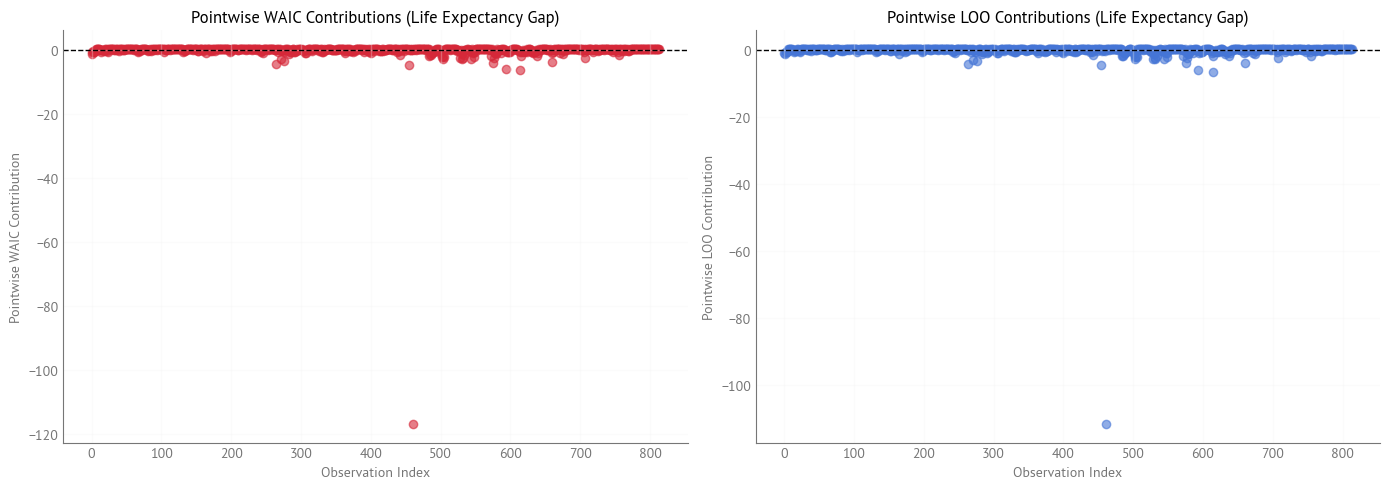

In [91]:
# Plot WAIC and LOO pointwise contributions
plot_waic_loo(
    waic_le, loo_le,
    model_name="Life Expectancy Gap",
    output_filename='jb/figs/waic_loo_le.png'
)

In [92]:
# Check Pareto k values for problematic observations
problematic_le = check_pareto_k(loo_le, data_le, model_name="Life Expectancy Gap")


Pareto k diagnostics (Life Expectancy Gap):
  Observations with k > 0.7: <xarray.DataArray 'pareto_shape' ()> Size: 8B
array(2) (0.2%)
  Maximum Pareto k: 2.439
  Mean Pareto k: 0.110
  Median Pareto k: 0.101

  Top problematic observations (k > 0.7):
 Observation  Pareto_k Country  Year
         461  2.438676     ISR  2021
         614  0.850875     MEX  2020


In [93]:
# Identify observations with high influence (high |LOO contribution|)
top_influential_le = identify_influential_observations(
    loo_le, data_le,
    model_name="Life Expectancy Gap",
    output_filename='jb/tables/influential_observations_le.html'
)
top_influential_le

Top 10 most influential observations (Life Expectancy Gap):
     Observation       LOO_i   Abs_LOO_i  Pareto_k
461          461 -111.450886  111.450886  2.438676
614          614   -6.581794    6.581794  0.850875
593          593   -6.143972    6.143972  0.522667
454          454   -4.661469    4.661469  0.172210
264          264   -4.364927    4.364927  0.437308
575          575   -4.062475    4.062475  0.155371
660          660   -3.844092    3.844092  0.250231
276          276   -3.503644    3.503644  0.130510
271          271   -3.046025    3.046025  0.371249
503          503   -2.882027    2.882027  0.158303


,Observation,Country,Year,LOO_i,Abs_LOO_i,Pareto_k
461,461,ISR,2021,-111.450886,111.450886,2.438676
614,614,MEX,2020,-6.581794,6.581794,0.850875
593,593,LVA,2021,-6.143972,6.143972,0.522667
454,454,ISR,2014,-4.661469,4.661469,0.172210
264,264,EST,2000,-4.364927,4.364927,0.437308
575,575,LVA,2003,-4.062475,4.062475,0.155371
660,660,NZL,2000,-3.844092,3.844092,0.250231
276,276,EST,2012,-3.503644,3.503644,0.130510
271,271,EST,2007,-3.046025,3.046025,0.371249
503,503,JPN,2019,-2.882027,2.882027,0.158303


### Model Comparison Summary

In [94]:
# Create summary table comparing HALE and Life Expectancy models
# Both WAIC and LOO are on ELPD scale
model_comparison = pd.DataFrame({
    'Model': ['HALE Gap', 'Life Expectancy Gap'],
    'WAIC (ELPD)': [waic_hale.elpd_waic, waic_le.elpd_waic],
    'WAIC_SE': [waic_hale.se, waic_le.se],
    'LOO (ELPD)': [loo_hale.elpd_loo, loo_le.elpd_loo],
    'LOO_SE': [loo_hale.se, loo_le.se],
    'p_waic': [waic_hale.p_waic, waic_le.p_waic],
    'p_loo': [loo_hale.p_loo, loo_le.p_loo],
})

print("Model Comparison Summary:")
print(model_comparison.to_string(index=False))

Model Comparison Summary:
              Model  WAIC (ELPD)    WAIC_SE  LOO (ELPD)     LOO_SE    p_waic     p_loo
           HALE Gap   -38.068233  77.432340  -36.769765  75.397717 66.516426 65.217959
Life Expectancy Gap  -174.997861 118.317959 -170.107611 112.948298 75.881479 70.991228


In [95]:
# Write model comparison table to HTML
write_html_table(model_comparison, get_output_filename('jb/tables/model_comparison_metrics.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

## R² and Residual Analysis

Compute R² (explained variance) and perform residual analysis for comparison with Elastic Net models and diagnostic purposes.

### Helper Functions for R² and Residual Analysis

In [96]:
def compute_predictions_and_residuals(trace, data, include_year_effects=False):
    """
    Compute posterior mean predictions and residuals for all observations.
    
    Parameters
    ----------
    trace : arviz.InferenceData
        Posterior trace from MCMC sampling
    data : dict
        Data dictionary with 'X' (standardized), 'y_centered', 'meta', etc.
    include_year_effects : bool
        Whether year effects were included in the model
        
    Returns
    -------
    dict
        Dictionary with predictions, residuals, and metadata
    """
    # Extract posterior samples
    beta_samples = trace.posterior['beta'].values.reshape(-1, len(data['meta']['predictors']))
    alpha_samples = trace.posterior['alpha'].values.reshape(-1, len(data['meta']['countries']))
    
    # Get data
    X_std = data['X']  # Already standardized
    y_centered = data['y_centered']
    y_mean = data['meta']['y_mean']
    y_original = y_centered + y_mean  # Reconstruct original scale
    country_idx = data['country_idx']
    
    # Get year indices if year effects were included
    if include_year_effects:
        year_idx = data['year_idx']
        gamma_samples = trace.posterior['gamma'].values.reshape(-1, len(data['meta']['years']))
    else:
        year_idx = None
        gamma_samples = None
    
    # Compute predictions for each posterior sample
    n_samples = beta_samples.shape[0]
    n_obs = len(y_centered)
    predictions_centered = np.zeros((n_samples, n_obs))
    
    for i in range(n_samples):
        # Get country-specific intercepts
        alpha_i = alpha_samples[i, country_idx]
        
        # Linear predictor: alpha + X @ beta
        mu_centered = alpha_i + np.dot(X_std, beta_samples[i])
        
        # Add year effects if included
        if include_year_effects:
            gamma_i = gamma_samples[i, year_idx]
            mu_centered = mu_centered + gamma_i
        
        predictions_centered[i] = mu_centered
    
    # Convert to original scale
    predictions_original = predictions_centered + y_mean
    
    # Compute posterior mean predictions
    y_pred_mean = np.mean(predictions_original, axis=0)
    
    # Compute residuals (on original scale)
    residuals = y_original - y_pred_mean
    
    # Compute posterior distribution of R²
    r2_samples = []
    for i in range(n_samples):
        y_pred_i = predictions_original[i]
        ss_res = np.sum((y_original - y_pred_i) ** 2)
        ss_tot = np.sum((y_original - y_mean) ** 2)
        r2_i = 1 - (ss_res / ss_tot)
        r2_samples.append(r2_i)
    
    r2_samples = np.array(r2_samples)
    r2_mean = np.mean(r2_samples)
    r2_hdi = az.hdi(r2_samples, hdi_prob=0.94)
    
    return {
        'y_pred_mean': y_pred_mean,
        'y_pred_samples': predictions_original,
        'residuals': residuals,
        'r2_mean': r2_mean,
        'r2_samples': r2_samples,
        'r2_hdi': r2_hdi,
        'y_original': y_original,
        'y_mean': y_mean,
    }


def plot_residuals_vs_predicted(y_pred, residuals, title, output_filename):
    """
    Plot residuals vs. predicted values.
    
    Parameters
    ----------
    y_pred : array-like
        Predicted values
    residuals : array-like
        Residuals
    title : str
        Plot title
    output_filename : str
        Output filename for saved figure
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(y_pred, residuals, color=AIBM_COLORS['crimson'], alpha=0.6)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted Value (years)', fontsize=12)
    ax.set_ylabel('Residual (years)', fontsize=12)
    ax.set_title(f'Residuals vs. Predicted Values: {title}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()


def plot_residuals_vs_country(residuals, country_idx, countries, years_data, title, output_filename):
    """
    Plot residuals by country for 2019 only.
    
    Parameters
    ----------
    residuals : array-like
        Residuals
    country_idx : array-like
        Country indices for each observation
    countries : array-like
        List of country codes
    years_data : array-like
        Year for each observation
    title : str
        Plot title
    output_filename : str
        Output filename for saved figure
    """
    # Create DataFrame for easier plotting
    df = pd.DataFrame({
        'Country': [countries[i] for i in country_idx],
        'Residual': residuals,
        'Year': years_data
    })
    
    # Filter to 2019 only
    df_2019 = df[df['Year'] == 2019].copy()
    
    # Sort by residual value
    df_2019_sorted = df_2019.sort_values('Residual')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    y_pos = np.arange(len(df_2019_sorted))
    colors = [AIBM_COLORS['crimson'] if x < 0 else AIBM_COLORS['blue'] for x in df_2019_sorted['Residual'].values]
    ax.barh(y_pos, df_2019_sorted['Residual'].values, color=colors, alpha=0.7)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_2019_sorted['Country'].values)
    ax.set_xlabel('Residual (years)', fontsize=12)
    ax.set_title(f'Residuals by Country (2019): {title}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()


def plot_residuals_vs_year(residuals, years_data, title, output_filename):
    """
    Plot residuals vs. year.
    
    Parameters
    ----------
    residuals : array-like
        Residuals
    years_data : array-like
        Year for each observation
    title : str
        Plot title
    output_filename : str
        Output filename for saved figure
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(years_data, residuals, color=AIBM_COLORS['crimson'], alpha=0.6)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Residual (years)', fontsize=12)
    ax.set_title(f'Residuals vs. Year: {title}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()


def plot_residual_histogram(residuals, title, output_filename):
    """
    Plot histogram of residuals.
    
    Parameters
    ----------
    residuals : array-like
        Residuals
    title : str
        Plot title
    output_filename : str
        Output filename for saved figure
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.hist(residuals, bins=20, color=AIBM_COLORS['crimson'], edgecolor='white', alpha=0.7)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=np.mean(residuals), color='black', linestyle='-', linewidth=2, label=f'Mean: {np.mean(residuals):.3f}')
    ax.set_xlabel('Residual (years)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'Distribution of Residuals: {title}', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()

### HALE Gap Model: R² and Residuals

In [97]:
# Compute predictions and residuals for HALE model
results_hale = compute_predictions_and_residuals(
    trace_hale, data_hale, include_year_effects=INCLUDE_YEAR_EFFECTS
)

# Print R² summary
print("HALE Gap Model: R² Summary")
print("="*60)
print(f"R² (mean): {results_hale['r2_mean']:.4f}")
print(f"R² (94% HDI): [{results_hale['r2_hdi'][0]:.4f}, {results_hale['r2_hdi'][1]:.4f}]")
print(f"\nResidual Statistics:")
print(f"  Mean: {np.mean(results_hale['residuals']):.4f} years")
print(f"  Std: {np.std(results_hale['residuals']):.4f} years")
print(f"  Min: {np.min(results_hale['residuals']):.4f} years")
print(f"  Max: {np.max(results_hale['residuals']):.4f} years")
print(f"  MAE: {np.mean(np.abs(results_hale['residuals'])):.4f} years")

HALE Gap Model: R² Summary
R² (mean): 0.9827
R² (94% HDI): [0.9823, 0.9831]

Residual Statistics:
  Mean: -0.0002 years
  Std: 0.2348 years
  Min: -2.7388 years
  Max: 0.8352 years
  MAE: 0.1687 years


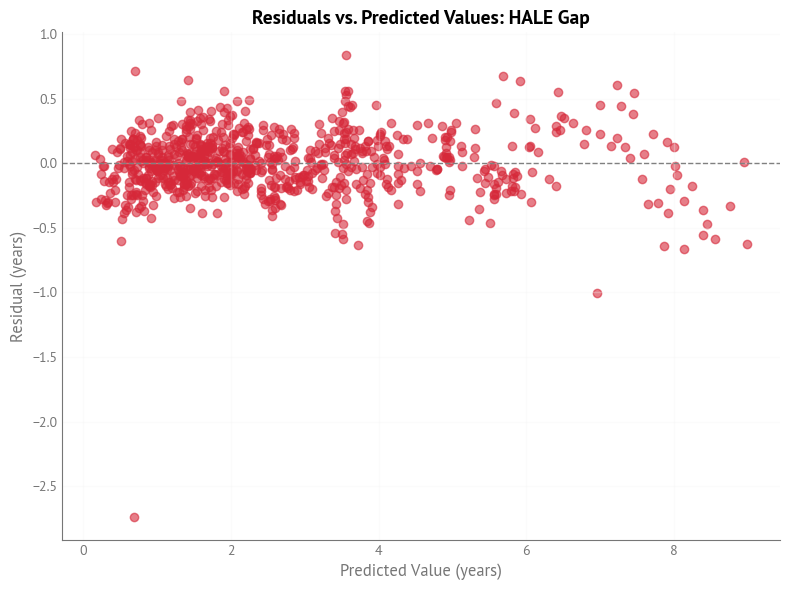

In [98]:
# Residuals vs. Predicted Values
plot_residuals_vs_predicted(
    results_hale['y_pred_mean'],
    results_hale['residuals'],
    "HALE Gap",
    get_output_filename('jb/figs/residuals_vs_predicted_hale.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
)

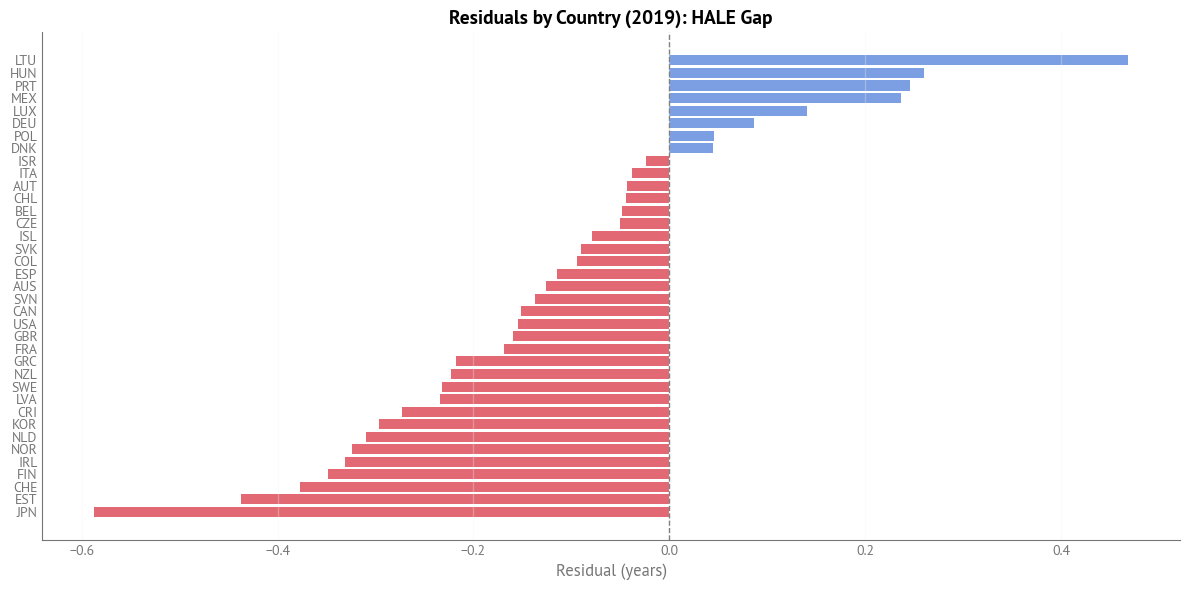

In [99]:
# Residuals vs. Country (2019 only)
# Get year data for each observation
years_data_hale = np.array([data_hale['meta']['years'][i] for i in data_hale['year_idx']])
plot_residuals_vs_country(
    results_hale['residuals'],
    data_hale['country_idx'],
    data_hale['meta']['countries'],
    years_data_hale,
    "HALE Gap",
    get_output_filename('jb/figs/residuals_vs_country_hale.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
)

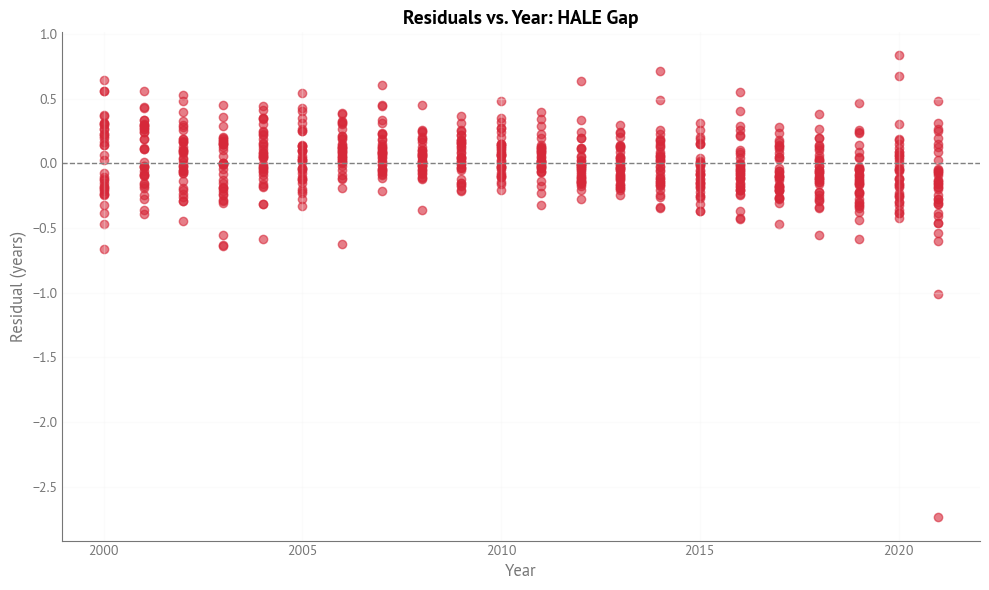

In [100]:
# Residuals vs. Year
plot_residuals_vs_year(
    results_hale['residuals'],
    years_data_hale,
    "HALE Gap",
    get_output_filename('jb/figs/residuals_vs_year_hale.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
)

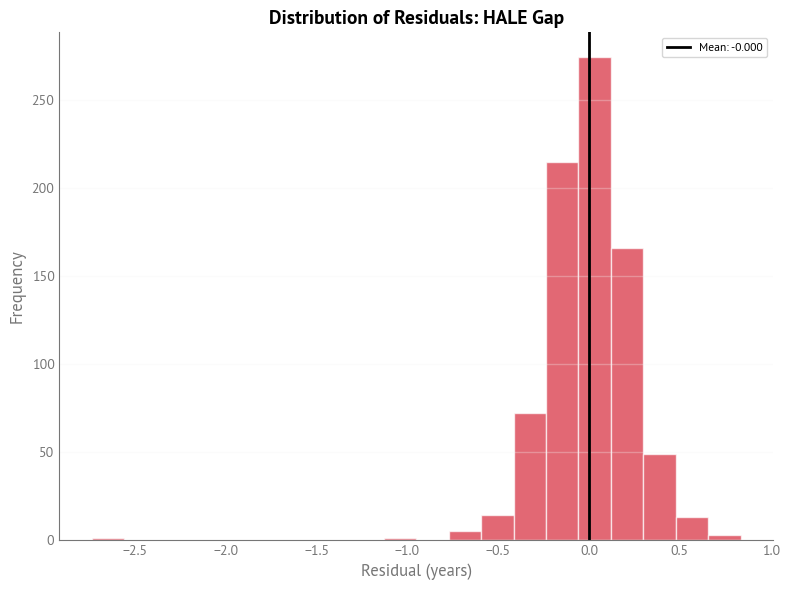

In [101]:
# Residual Histogram
plot_residual_histogram(
    results_hale['residuals'],
    "HALE Gap",
    get_output_filename('jb/figs/residuals_histogram_hale.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
)

In [102]:
# Create residual summary table for HALE
residual_summary_hale = pd.DataFrame({
    'Statistic': ['Mean', 'Std', 'Min', '25%', 'Median', '75%', 'Max', 'MAE'],
    'Value (years)': [
        np.mean(results_hale['residuals']),
        np.std(results_hale['residuals']),
        np.min(results_hale['residuals']),
        np.percentile(results_hale['residuals'], 25),
        np.median(results_hale['residuals']),
        np.percentile(results_hale['residuals'], 75),
        np.max(results_hale['residuals']),
        np.mean(np.abs(results_hale['residuals']))
    ]
})

residual_summary_hale['Value (years)'] = residual_summary_hale['Value (years)'].round(4)
residual_summary_hale

,Statistic,Value (years)
0,Mean,-0.0002
1,Std,0.2348
2,Min,-2.7388
3,25%,-0.1321
4,Median,-0.0069
5,75%,0.1340
6,Max,0.8352
7,MAE,0.1687


In [103]:
# Write residual summary to HTML
write_html_table(
    residual_summary_hale,
    get_output_filename('jb/tables/residual_summary_hale.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
)

### Life Expectancy Gap Model: R² and Residuals

In [104]:
# Compute predictions and residuals for Life Expectancy model
results_le = compute_predictions_and_residuals(
    trace_le, data_le, include_year_effects=INCLUDE_YEAR_EFFECTS
)

# Print R² summary
print("Life Expectancy Gap Model: R² Summary")
print("="*60)
print(f"R² (mean): {results_le['r2_mean']:.4f}")
print(f"R² (94% HDI): [{results_le['r2_hdi'][0]:.4f}, {results_le['r2_hdi'][1]:.4f}]")
print(f"\nResidual Statistics:")
print(f"  Mean: {np.mean(results_le['residuals']):.4f} years")
print(f"  Std: {np.std(results_le['residuals']):.4f} years")
print(f"  Min: {np.min(results_le['residuals']):.4f} years")
print(f"  Max: {np.max(results_le['residuals']):.4f} years")
print(f"  MAE: {np.mean(np.abs(results_le['residuals'])):.4f} years")

Life Expectancy Gap Model: R² Summary
R² (mean): 0.9779
R² (94% HDI): [0.9774, 0.9785]

Residual Statistics:
  Mean: 0.0002 years
  Std: 0.2754 years
  Min: -3.9292 years
  Max: 0.8741 years
  MAE: 0.1886 years


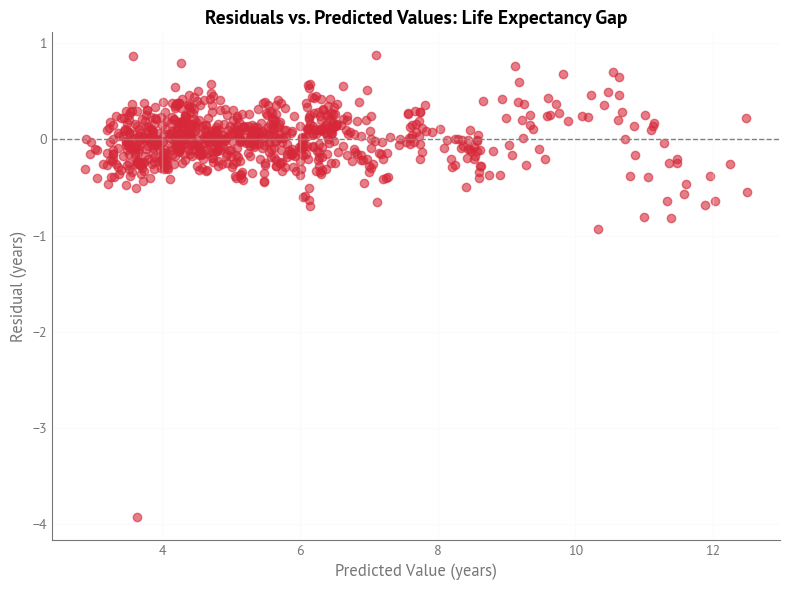

In [105]:
# Residuals vs. Predicted Values
plot_residuals_vs_predicted(
    results_le['y_pred_mean'],
    results_le['residuals'],
    "Life Expectancy Gap",
    get_output_filename('jb/figs/residuals_vs_predicted_le.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
)

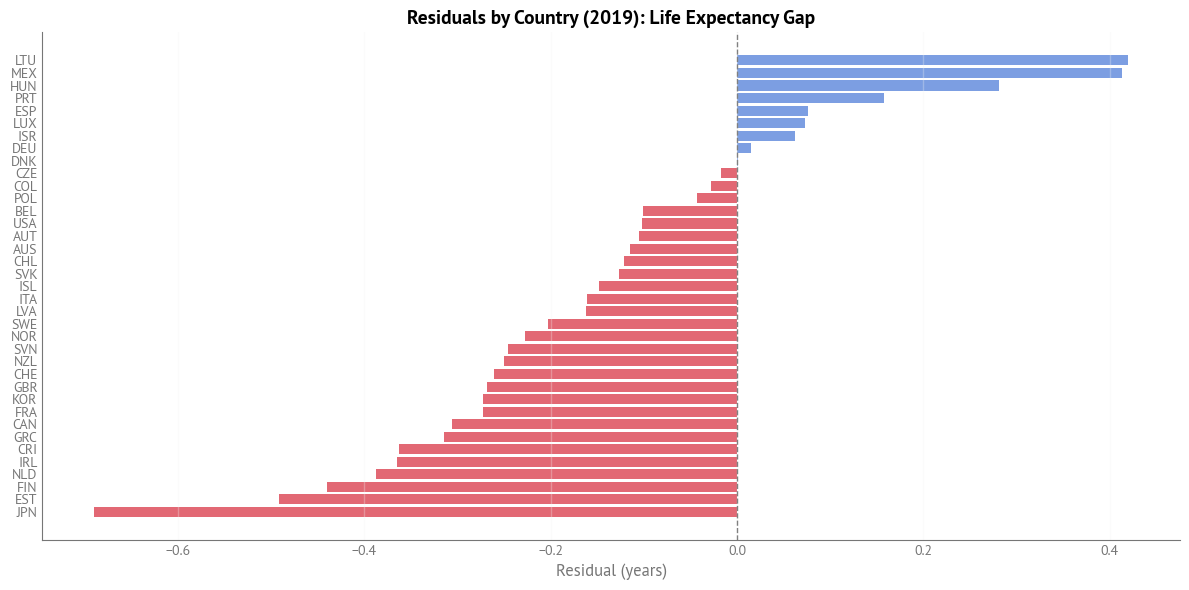

In [106]:
# Residuals vs. Country (2019 only)
# Get year data for each observation
years_data_le = np.array([data_le['meta']['years'][i] for i in data_le['year_idx']])
plot_residuals_vs_country(
    results_le['residuals'],
    data_le['country_idx'],
    data_le['meta']['countries'],
    years_data_le,
    "Life Expectancy Gap",
    get_output_filename('jb/figs/residuals_vs_country_le.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
)

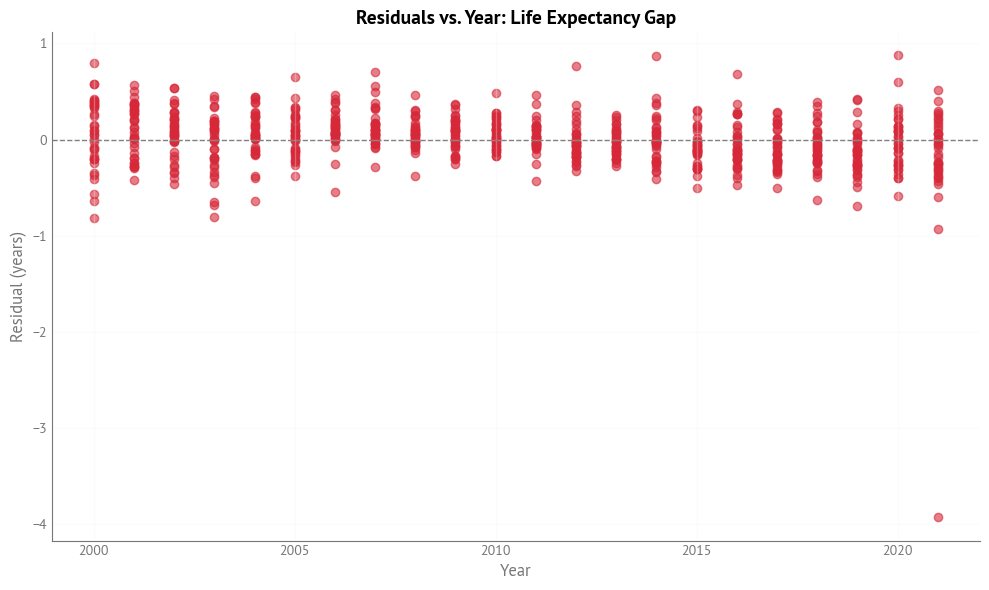

In [107]:
# Residuals vs. Year
plot_residuals_vs_year(
    results_le['residuals'],
    years_data_le,
    "Life Expectancy Gap",
    get_output_filename('jb/figs/residuals_vs_year_le.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
)

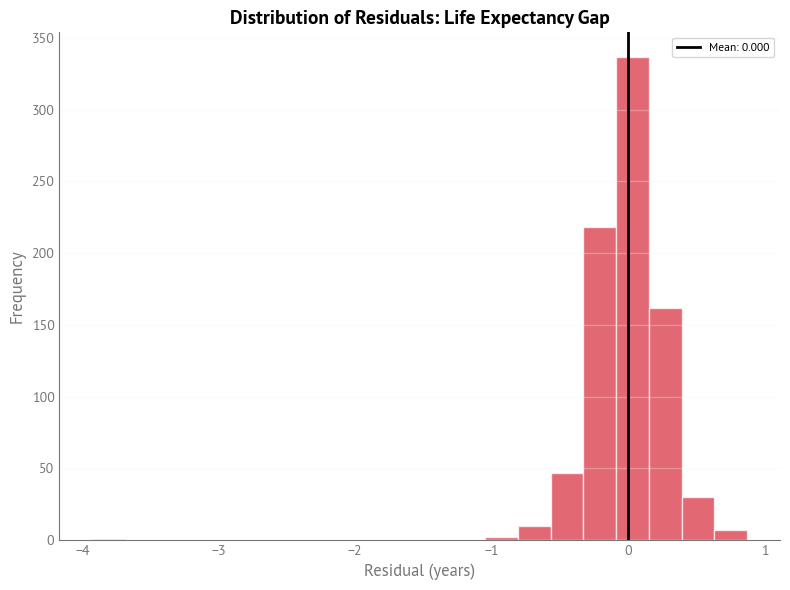

In [108]:
# Residual Histogram
plot_residual_histogram(
    results_le['residuals'],
    "Life Expectancy Gap",
    get_output_filename('jb/figs/residuals_histogram_le.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
)

In [109]:
# Create residual summary table for Life Expectancy
residual_summary_le = pd.DataFrame({
    'Statistic': ['Mean', 'Std', 'Min', '25%', 'Median', '75%', 'Max', 'MAE'],
    'Value (years)': [
        np.mean(results_le['residuals']),
        np.std(results_le['residuals']),
        np.min(results_le['residuals']),
        np.percentile(results_le['residuals'], 25),
        np.median(results_le['residuals']),
        np.percentile(results_le['residuals'], 75),
        np.max(results_le['residuals']),
        np.mean(np.abs(results_le['residuals']))
    ]
})

residual_summary_le['Value (years)'] = residual_summary_le['Value (years)'].round(4)
residual_summary_le

,Statistic,Value (years)
0,Mean,0.0002
1,Std,0.2754
2,Min,-3.9292
3,25%,-0.1477
4,Median,0.0058
5,75%,0.1474
6,Max,0.8741
7,MAE,0.1886


In [110]:
# Write residual summary to HTML
write_html_table(
    residual_summary_le,
    get_output_filename('jb/tables/residual_summary_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
)

### R² Comparison Summary

In [111]:
# Create R² comparison table
r2_comparison = pd.DataFrame({
    'Model': ['HALE Gap', 'Life Expectancy Gap'],
    'R² (mean)': [results_hale['r2_mean'], results_le['r2_mean']],
    'R² (94% HDI lower)': [results_hale['r2_hdi'][0], results_le['r2_hdi'][0]],
    'R² (94% HDI upper)': [results_hale['r2_hdi'][1], results_le['r2_hdi'][1]],
    'MAE (years)': [
        np.mean(np.abs(results_hale['residuals'])),
        np.mean(np.abs(results_le['residuals']))
    ],
    'Residual Std (years)': [
        np.std(results_hale['residuals']),
        np.std(results_le['residuals'])
    ]
})

r2_comparison = r2_comparison.round(4)
print("R² and Residual Summary:")
print("="*60)
print(r2_comparison.to_string(index=False))

R² and Residual Summary:
              Model  R² (mean)  R² (94% HDI lower)  R² (94% HDI upper)  MAE (years)  Residual Std (years)
           HALE Gap     0.9827              0.9823              0.9831       0.1687                0.2348
Life Expectancy Gap     0.9779              0.9774              0.9785       0.1886                0.2754


In [112]:
# Write R² comparison to HTML
write_html_table(
    r2_comparison,
    get_output_filename('jb/tables/r2_comparison.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
)

## Save Model Results for Counterfactual Analysis

Save all necessary data for counterfactual analysis in a separate notebook:

In [113]:
import json
from pathlib import Path

# Create output directory if it doesn't exist
output_dir = Path('../data/bayesian_model_results')
output_dir.mkdir(exist_ok=True)

# Generate filename suffix based on model configuration
# Construct suffix directly from configuration (matching get_output_filename logic)
if MID_PREDICTORS_TO_INCLUDE is None or len(MID_PREDICTORS_TO_INCLUDE) == 0:
    mid_suffix = 'nomid'
else:
    # Create short names for each Mid predictor (matching get_output_filename)
    short_names = {
        'Mid_Cardiovascular': 'cardio',
        'Mid_Diabetes': 'diabetes',
        'Mid_ChronicRespiratory': 'respiratory',
        'Mid_UnintentionalInjury': 'unintentional',
        'Mid_Neoplasms': 'neoplasms',
    }
    mid_parts = []
    for mid_pred in sorted(MID_PREDICTORS_TO_INCLUDE):
        short_name = short_names.get(mid_pred, mid_pred.replace('Mid_', '').lower())
        mid_parts.append(short_name)
    mid_suffix = 'mid' + '_'.join(mid_parts)

grw_suffix = 'yesgrw' if INCLUDE_YEAR_EFFECTS else 'nogrw'
year_suffix = f'y{CUTOFF_YEAR}'
covid_suffix = 'covid' if INCLUDE_COVID_DATA else 'nocovid'
suffix = f'_{mid_suffix}_{grw_suffix}_{year_suffix}_{covid_suffix}'

### Save Traces (NetCDF Format)

In [114]:
# Save HALE trace to NetCDF
trace_filename_hale = output_dir / f'trace_hale{suffix}.nc'
# Delete file if it exists to avoid locking issues
if trace_filename_hale.exists():
    trace_filename_hale.unlink()
trace_hale.to_netcdf(trace_filename_hale)
print(f"Saved HALE trace to: {trace_filename_hale}")

# Save Life Expectancy trace to NetCDF
trace_filename_le = output_dir / f'trace_le{suffix}.nc'
# Delete file if it exists to avoid locking issues
if trace_filename_le.exists():
    trace_filename_le.unlink()
trace_le.to_netcdf(trace_filename_le)
print(f"Saved Life Expectancy trace to: {trace_filename_le}")

Saved HALE trace to: ../data/bayesian_model_results/trace_hale_nomid_nogrw_y2021_covid.nc
Saved Life Expectancy trace to: ../data/bayesian_model_results/trace_le_nomid_nogrw_y2021_covid.nc


### Save Metadata

In [115]:
# Save metadata for HALE model
meta_hale = {
    'X_mean': data_hale['meta']['X_mean'].tolist(),  # Convert numpy array to list for JSON
    'X_std': data_hale['meta']['X_std'].tolist(),
    'y_mean': float(data_hale['meta']['y_mean']),  # Convert numpy scalar to float
    'countries': data_hale['meta']['countries'].tolist(),
    'years': data_hale['meta']['years'].tolist(),
    'predictors': data_hale['meta']['predictors'],
    'model_config': {
        'mid_predictors_included': MID_PREDICTORS_TO_INCLUDE,
        'include_year_effects': INCLUDE_YEAR_EFFECTS,
        'countries_excluded': COUNTRIES_TO_EXCLUDE,
        'cutoff_year': CUTOFF_YEAR,
        'include_covid_data': INCLUDE_COVID_DATA,
    }
}

meta_filename_hale = output_dir / f'metadata_hale{suffix}.json'
with open(meta_filename_hale, 'w') as f:
    json.dump(meta_hale, f, indent=2)
print(f"Saved HALE metadata to: {meta_filename_hale}")

# Save metadata for Life Expectancy model
meta_le = {
    'X_mean': data_le['meta']['X_mean'].tolist(),
    'X_std': data_le['meta']['X_std'].tolist(),
    'y_mean': float(data_le['meta']['y_mean']),
    'countries': data_le['meta']['countries'].tolist(),
    'years': data_le['meta']['years'].tolist(),
    'predictors': data_le['meta']['predictors'],
    'model_config': {
        'mid_predictors_included': MID_PREDICTORS_TO_INCLUDE,
        'include_year_effects': INCLUDE_YEAR_EFFECTS,
        'countries_excluded': COUNTRIES_TO_EXCLUDE,
        'cutoff_year': CUTOFF_YEAR,
        'include_covid_data': INCLUDE_COVID_DATA,
    }
}

meta_filename_le = output_dir / f'metadata_le{suffix}.json'
with open(meta_filename_le, 'w') as f:
    json.dump(meta_le, f, indent=2)
print(f"Saved Life Expectancy metadata to: {meta_filename_le}")

Saved HALE metadata to: ../data/bayesian_model_results/metadata_hale_nomid_nogrw_y2021_covid.json
Saved Life Expectancy metadata to: ../data/bayesian_model_results/metadata_le_nomid_nogrw_y2021_covid.json


### Save Panel Dataset

In [116]:
# Save panel dataset with all Mid and Gap columns for counterfactual analysis
# This dataset is needed to:
# 1. Look up current values for any country-year
# 2. Reconstruct Male/Female values from Mid and Gap (Male = Mid + Gap/2, Female = Mid - Gap/2)
# 3. Find gap extremes across all country-years

panel_filename = output_dir / f'panel_dataset{suffix}.h5'
panel_df.to_hdf(panel_filename, key='panel_data', mode='w')
print(f"Saved panel dataset to: {panel_filename}")
print(f"Panel dataset shape: {panel_df.shape}")
print(f"Columns: {list(panel_df.columns)}")

Saved panel dataset to: ../data/bayesian_model_results/panel_dataset_nomid_nogrw_y2021_covid.h5
Panel dataset shape: (814, 28)
Columns: ['country', 'Year', 'HALE_gap', 'LE_gap', 'Mid_Alcohol', 'Gap_Alcohol', 'Mid_Suicide', 'Gap_Suicide', 'Mid_Homicide', 'Gap_Homicide', 'Mid_RoadTraffic', 'Gap_RoadTraffic', 'Mid_Cardiovascular', 'Gap_Cardiovascular', 'Mid_Diabetes', 'Gap_Diabetes', 'Mid_Neoplasms', 'Gap_Neoplasms', 'Mid_ChronicRespiratory', 'Gap_ChronicRespiratory', 'Mid_LiverDisease', 'Gap_LiverDisease', 'Mid_UnintentionalInjury', 'Gap_UnintentionalInjury', 'Mid_DrugDisorder', 'Gap_DrugDisorder', 'Mid_COVID', 'Gap_COVID']


### Summary

In [117]:
print("\n" + "="*60)
print("Summary of Saved Files for Counterfactual Analysis")
print("="*60)
print(f"\nOutput directory: {output_dir}")
print(f"\nFiles saved:")
print(f"  1. HALE trace (NetCDF): {trace_filename_hale.name}")
print(f"  2. Life Expectancy trace (NetCDF): {trace_filename_le.name}")
print(f"  3. HALE metadata (JSON): {meta_filename_hale.name}")
print(f"  4. Life Expectancy metadata (JSON): {meta_filename_le.name}")
print(f"  5. Panel dataset (HDF5): {panel_filename.name}")
print(f"\nNote: Model objects are not saved (PyMC models cannot be pickled).")
print(f"      The traces and metadata contain all information needed for counterfactual analysis.")
print(f"\nModel configuration:")
print(f"  - Cutoff year: {CUTOFF_YEAR}")
print(f"  - Include COVID data: {INCLUDE_COVID_DATA}")
print(f"  - Mid predictors included: {MID_PREDICTORS_TO_INCLUDE}")
print(f"  - Year effects included: {INCLUDE_YEAR_EFFECTS}")
print(f"  - Countries excluded: {COUNTRIES_TO_EXCLUDE}")
print(f"\nAll files are ready for counterfactual analysis in bayes_counter.md")


Summary of Saved Files for Counterfactual Analysis

Output directory: ../data/bayesian_model_results

Files saved:
  1. HALE trace (NetCDF): trace_hale_nomid_nogrw_y2021_covid.nc
  2. Life Expectancy trace (NetCDF): trace_le_nomid_nogrw_y2021_covid.nc
  3. HALE metadata (JSON): metadata_hale_nomid_nogrw_y2021_covid.json
  4. Life Expectancy metadata (JSON): metadata_le_nomid_nogrw_y2021_covid.json
  5. Panel dataset (HDF5): panel_dataset_nomid_nogrw_y2021_covid.h5

Note: Model objects are not saved (PyMC models cannot be pickled).
      The traces and metadata contain all information needed for counterfactual analysis.

Model configuration:
  - Cutoff year: 2021
  - Include COVID data: True
  - Mid predictors included: []
  - Year effects included: False
  - Countries excluded: ['TUR']

All files are ready for counterfactual analysis in bayes_counter.md


## Next Steps

- ✅ Posterior predictive checks
- ✅ WAIC and LOO-CV
- Counterfactual analysis with uncertainty quantification
- Model extensions (year fixed effects, AR(1) structure)



In [118]:
from utils import beep

beep()